# Step 5A: 듀얼 모멘텀 + 자산별 최적 Q — Black-Litterman

## Step5 대비 두 가지 차이점

| 항목 | Step5 (기본) | Step5A (이 노트북) |
|------|------------|-----------------|
| **Q 윈도우** | 전 자산 동일 (126/189/252일 평균) | 자산별 IC 최적 윈도우 사용 |
| **편출 조건** | 없음 — 항상 61개 보유 | **절대 모멘텀 < T-bill → 비중 0, 나머지에 재분배** |

### 듀얼 모멘텀 (Antonacci, 2014)
```
Step 1. 절대 모멘텀 필터
   → 각 자산의 12-1 수익률 > T-bill(SHY proxy)?
   → NO  : 편출 — 해당 자산 비중 0, 나머지 active 자산에 재분배
   → YES : Step 2

Step 2. 상대 모멘텀 (BL Q)
   → IC 분석으로 각 자산별 최적 모멘텀 윈도우 선정 (셀 8-C/8-D)
   → 자산별 최적 윈도우로 Q 계산 → BL 입력
```


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import warnings
import time
import pickle
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

BASE = Path('.')
DATA = BASE / 'data'
IMAGES = BASE / 'images'
CACHE = DATA / 'stock5_cache'
DATA.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)
CACHE.mkdir(exist_ok=True)

print('준비 완료')

준비 완료


## 셀 2: S&P 500 후보 풀 정의

**동적 후보 풀**: 현재 S&P 500 전체 종목을 Wikipedia에서 수집.  
매 리밸런싱 연도 기준으로 Wikipedia 변경이력 필터를 적용해 **당시 S&P 500에 있었던 종목만** 후보로 사용.

→ 고정 종목 풀(SECTOR_CANDIDATES) 없음 — 모든 종목이 동적으로 결정됨

In [2]:
import io
import requests

def fetch_sp500_snapshot(cache_path=None):
    """
    Wikipedia에서 현재 S&P 500 전체 종목 + GICS 섹터 수집
    반환: DataFrame with columns [ticker, sector]
    """
    cache_path = cache_path or (CACHE / 'sp500_snapshot.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print('S&P 500 전체 목록 수집 중...')
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))

    df = tables[0].copy()
    df.columns = [str(c).strip() for c in df.columns]
    ticker_col = next(c for c in df.columns if 'symbol' in c.lower() or 'ticker' in c.lower())
    sector_col = next(
        c for c in df.columns
        if 'gics sector' in c.lower() or ('sector' in c.lower() and 'sub' not in c.lower())
    )
    result = df[[ticker_col, sector_col]].rename(
        columns={ticker_col: 'ticker', sector_col: 'sector'}
    ).copy()
    result['ticker'] = result['ticker'].str.replace('.', '-', regex=False).str.strip()
    result = result.dropna().reset_index(drop=True)

    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    print(f'S&P 500 종목 {len(result)}개 수집 ({result["sector"].nunique()}개 섹터)')
    return result


TOP_N              = 5            # 섹터당 선정 종목 수
REBALANCE_FREQ     = 21           # 21거래일마다 BL 리밸런싱
UNIVERSE_UPDATE_FREQ = 252        # 252거래일(1년)마다 유니버스 갱신
ANALYSIS_START     = '2016-01-01'
PRICE_START        = '2013-01-01' # 모멘텀(252일) + 공분산(252일) 여유 기간
PRICE_END          = '2025-12-31'
COV_WIN            = 252
TAU                = 1 / 252      # Prior 불확실성 (하루치 분산 스케일, He & Litterman 1992)
LAM                = 2.5          # 위험회피계수 λ

## 셀 2-B: S&P 500 변경이력으로 생존편향 완화

**핵심**: 현재 S&P 500 전체를 후보 풀로 사용하되, Wikipedia 변경이력으로
"분석 시점 이후에 편입된 종목"을 해당 시점의 후보 풀에서 제거.

예) 2016년 1월 기준 백테스트 시점:
- TSLA (2020년 편입) → 제거
- AVGO (2017년 편입) → 제거  
- AAPL, MSFT 등 2016년 이전 편입 종목 → 유지

**한계**: Wikipedia는 주요 변경만 기록 (완전하지 않음). 분석 기간 중 퇴출된
종목(파산·합병 등)은 복원 불가 → 이 한계를 명시적으로 논문에 기재 필요.


In [3]:
# ── Wikipedia S&P 500 변경이력 수집 ──────────────────────────────────────

def fetch_sp500_changes(cache_path=None):
    """Wikipedia S&P 500 변경이력 테이블 파싱
    반환: DataFrame with columns [date, added, removed]
    """
    cache_path = cache_path or (CACHE / 'sp500_changes.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print('Wikipedia S&P 500 변경이력 다운로드 중...')
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))
    raw = tables[1].copy()
    raw.columns = [str(c).strip() for c in raw.columns]
    date_col = raw.columns[0]
    def find_col(df, keywords):
        for c in df.columns:
            if any(k.lower() in str(c).lower() for k in keywords):
                return c
        return None
    added_col   = find_col(raw, ['added', 'add']) or raw.columns[1]
    removed_col = find_col(raw, ['removed', 'remove']) or raw.columns[3]
    changes = pd.DataFrame({
        'date':    pd.to_datetime(raw[date_col], errors='coerce'),
        'added':   raw[added_col].astype(str).str.strip().str.replace('.', '-', regex=False),
        'removed': raw[removed_col].astype(str).str.strip().str.replace('.', '-', regex=False),
    }).dropna(subset=['date'])
    changes['added']   = changes['added'].replace({'nan': None, 'NaN': None, '': None})
    changes['removed'] = changes['removed'].replace({'nan': None, 'NaN': None, '': None})
    changes = changes.sort_values('date').reset_index(drop=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(changes, f)
    print(f'변경이력 {len(changes)}건 로드')
    return changes


def filter_pool_by_date(snapshot_df, changes_df, target_date):
    """target_date 이후 S&P 500에 편입된 종목을 후보 풀에서 제거
    Returns: filtered_df (DataFrame), excluded (list)
    """
    target_dt   = pd.Timestamp(target_date)
    added_after = set(
        changes_df.loc[
            (changes_df['date'] > target_dt) & changes_df['added'].notna(), 'added'
        ].dropna()
    )
    filtered_df = snapshot_df[~snapshot_df['ticker'].isin(added_after)].reset_index(drop=True)
    excluded    = sorted(set(snapshot_df['ticker']) & added_after)
    return filtered_df, excluded


# ── 데이터 수집 실행 ──────────────────────────────────────────────────────
sp500_snapshot = fetch_sp500_snapshot()
sp500_changes  = fetch_sp500_changes()

# 2016-01-01 기준 필터링 테스트
filtered_2016, excluded_2016 = filter_pool_by_date(
    sp500_snapshot, sp500_changes, '2016-01-01')
print(f'\n2016-01-01 기준 필터링:')
print(f'  전체 풀: {len(sp500_snapshot)}개')
print(f'  필터링 후: {len(filtered_2016)}개')
print(f'  제외 종목 ({len(excluded_2016)}개, 일부): {excluded_2016[:8]}{"..." if len(excluded_2016) > 8 else ""}')
print(f'  → 이 종목들은 2016년 이후 S&P 500에 편입됨')

# ── 가격 수집 및 섹터 맵핑에 사용할 변수 도출 ─────────────────────────────
ALL_CANDIDATES   = list(sp500_snapshot['ticker'].unique())
TICKER_TO_SECTOR = dict(zip(sp500_snapshot['ticker'], sp500_snapshot['sector']))
print(f'다운로드 대상: {len(ALL_CANDIDATES)}개 종목')



2016-01-01 기준 필터링:
  전체 풀: 503개
  필터링 후: 342개
  제외 종목 (161개, 일부): ['ABNB', 'ACGL', 'AJG', 'ALB', 'ALGN', 'AMCR', 'AMD', 'ANET']...
  → 이 종목들은 2016년 이후 S&P 500에 편입됨
다운로드 대상: 503개 종목


## 셀 3: 가격 데이터 수집

In [4]:
prices_cache = CACHE / 'prices_all_candidates.pkl'

if prices_cache.exists():
    with open(prices_cache, 'rb') as f:
        prices_raw = pickle.load(f)
    print(f'캐시 로드: {prices_raw.shape}')
else:
    print(f'{len(ALL_CANDIDATES)}개 종목 가격 다운로드 중 (2013-2025)...')
    prices_raw = yf.download(
        ALL_CANDIDATES,
        start=PRICE_START,
        end=PRICE_END,
        auto_adjust=True,
        progress=True
    )['Close']
    with open(prices_cache, 'wb') as f:
        pickle.dump(prices_raw, f)
    print(f'저장 완료: {prices_raw.shape}')

# 결측이 10% 이상인 종목 제거
valid_mask = prices_raw.notna().mean() >= 0.90
prices = prices_raw.loc[:, valid_mask].ffill()

# 유효 종목 → TICKER_TO_SECTOR 업데이트
valid_tickers    = set(prices.columns)
TICKER_TO_SECTOR = {t: s for t, s in TICKER_TO_SECTOR.items() if t in valid_tickers}

# sp500_snapshot도 유효 종목으로 필터링
sp500_snapshot = sp500_snapshot[
    sp500_snapshot['ticker'].isin(valid_tickers)
].reset_index(drop=True)

print(f'\n유효 종목: {len(valid_tickers)}개')
print(f'기간: {prices.index[0].date()} ~ {prices.index[-1].date()}')
for s, grp in sp500_snapshot.groupby('sector'):
    avail = [t for t in grp['ticker'] if t in valid_tickers]
    print(f'  {s[:30]:30s}: {len(avail)}개 가용')


캐시 로드: (3269, 503)

유효 종목: 457개
기간: 2013-01-02 ~ 2025-12-30
  Communication Services        : 20개 가용
  Consumer Discretionary        : 45개 가용
  Consumer Staples              : 34개 가용
  Energy                        : 21개 가용
  Financials                    : 69개 가용
  Health Care                   : 55개 가용
  Industrials                   : 70개 가용
  Information Technology        : 61개 가용
  Materials                     : 24개 가용
  Real Estate                   : 29개 가용
  Utilities                     : 29개 가용


## 셀 4: 발행주식수 수집 (시가총액 추정용)

시가총액 = 주가 × 발행주식수
- 현재 발행주식수를 가져와 역사적 시가총액의 프록시로 사용
- 김재천의 estimate_historical_market_cap 방식 참고

In [5]:
shares_cache = CACHE / 'shares_outstanding.pkl'

def fetch_shares_outstanding(tickers, cache_path):
    """yfinance info에서 발행주식수 수집 (캐시 지원)"""
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            shares_dict = pickle.load(f)
    else:
        shares_dict = {}

    missing = [t for t in tickers if t not in shares_dict]
    if missing:
        print(f'{len(missing)}개 종목 주식수 조회 중...')
        for i, ticker in enumerate(missing):
            try:
                info = yf.Ticker(ticker).info
                s = info.get('sharesOutstanding') or info.get('impliedSharesOutstanding')
                shares_dict[ticker] = float(s) if s else None
            except Exception:
                shares_dict[ticker] = None
            if (i + 1) % 30 == 0:
                print(f'  {i+1}/{len(missing)} 완료')
                time.sleep(1)
        with open(cache_path, 'wb') as f:
            pickle.dump(shares_dict, f)
        print('저장 완료')
    else:
        print(f'캐시 로드: {len(shares_dict)}개')

    return shares_dict


shares_dict = fetch_shares_outstanding(list(valid_tickers), shares_cache)

n_ok = sum(1 for v in shares_dict.values() if v and v > 0)
print(f'\n주식수 조회 성공: {n_ok}/{len(valid_tickers)}')

# 시가총액 스냅샷 (최신 기준)
latest = prices.iloc[-1]
mcap_latest = {
    t: latest.get(t, np.nan) * (shares_dict.get(t) or np.nan)
    for t in valid_tickers
}
mcap_series = pd.Series(mcap_latest).dropna() / 1e9  # 단위: 십억달러

print(f'\n시가총액 상위 10종목 (최신 기준):')
print(mcap_series.nlargest(10).apply(lambda x: f'${x:.0f}B').to_string())

캐시 로드: 457개

주식수 조회 성공: 457/457

시가총액 상위 10종목 (최신 기준):
NVDA     $4557B
AAPL     $4005B
MSFT     $3612B
AMZN     $2501B
GOOGL    $1826B
GOOG     $1709B
TSLA     $1705B
AVGO     $1653B
META     $1461B
LLY       $963B


## 셀 5: 동적 유니버스 선정 함수

In [6]:
def select_universe_by_mcap(price_snap, shares_dict, pool_df, top_n=5):
    """
    특정 시점 가격 스냅샷 기준 섹터별 시가총액 상위 top_n 종목 선정

    Parameters
    ----------
    price_snap  : pd.Series   - 해당 시점 종가
    shares_dict : dict        - 종목별 발행주식수
    pool_df     : DataFrame   - 후보 풀 (columns: ticker, sector)
    top_n       : int         - 섹터당 선정 수

    Returns
    -------
    universe    : list        - 선정된 종목 리스트
    sector_map  : dict        - 섹터 → 선정 종목 매핑
    w_mkt       : pd.Series   - 시가총액 비중 (참고용)
    """
    sector_map = {}
    mcap_map   = {}

    for sector, grp in pool_df.groupby('sector'):
        avail = [
            t for t in grp['ticker']
            if t in price_snap.index
            and pd.notna(price_snap.get(t, np.nan))
            and shares_dict.get(t, 0) > 0
        ]
        if not avail:
            continue
        mcap     = {t: price_snap[t] * shares_dict[t] for t in avail}
        selected = sorted(mcap.items(), key=lambda x: x[1], reverse=True)[:top_n]
        sector_map[sector] = [t for t, _ in selected]
        for t, m in selected:
            mcap_map[t] = m

    universe   = [t for ts in sector_map.values() for t in ts]
    total_mcap = sum(mcap_map.values()) or 1
    w_mkt      = pd.Series({t: mcap_map[t] / total_mcap for t in universe})
    return universe, sector_map, w_mkt


# ── 최신 시점 테스트 ──────────────────────────────────────────────────────
latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, prices.index[-1])
test_universe, test_sector_map, test_w_mkt = select_universe_by_mcap(
    prices.iloc[-1], shares_dict, latest_pool, TOP_N
)
print(f'선정된 종목 수: {len(test_universe)} ({len(test_sector_map)}섹터)')
print(f'\n섹터별 선정 종목:')
for sector, tickers in sorted(test_sector_map.items()):
    weights = [f"{t}({test_w_mkt[t]*100:.1f}%)" for t in tickers]
    print(f'  {sector[:25]:25s}: {" | ".join(weights)}')


선정된 종목 수: 55 (11섹터)

섹터별 선정 종목:
  Communication Services   : GOOGL(5.0%) | GOOG(4.7%) | META(4.0%) | NFLX(1.1%) | TMUS(0.6%)
  Consumer Discretionary   : AMZN(6.9%) | TSLA(4.7%) | HD(0.9%) | MCD(0.6%) | BKNG(0.5%)
  Consumer Staples         : WMT(2.5%) | COST(1.1%) | PG(0.9%) | KO(0.8%) | PM(0.7%)
  Energy                   : XOM(1.4%) | CVX(0.8%) | COP(0.3%) | WMB(0.2%) | KMI(0.2%)
  Financials               : JPM(2.4%) | BRK-B(1.9%) | V(1.6%) | MA(1.4%) | BAC(1.1%)
  Health Care              : LLY(2.7%) | JNJ(1.4%) | ABBV(1.1%) | UNH(0.8%) | MRK(0.7%)
  Industrials              : GE(0.9%) | CAT(0.7%) | RTX(0.7%) | BA(0.5%) | UNP(0.4%)
  Information Technology   : NVDA(12.6%) | AAPL(11.0%) | MSFT(10.0%) | AVGO(4.6%) | ORCL(1.6%)
  Materials                : LIN(0.5%) | NEM(0.3%) | CRH(0.2%) | SHW(0.2%) | ECL(0.2%)
  Real Estate              : WELL(0.4%) | PLD(0.3%) | AMT(0.2%) | EQIX(0.2%) | SPG(0.2%)
  Utilities                : NEE(0.5%) | SO(0.3%) | DUK(0.3%) | AEP(0.2%) | SRE(0.2%

## 셀 6: BL 핵심 함수 (시가총액 Prior 포함)

In [7]:
def compute_prior_risk_parity(cov, lam=2.5):
    """
    Risk Parity Prior: π = λΣw_rp
    Equal Risk Contribution (ERC): RC_i = w_i × (Σw)_i / σ_p → 모든 i 동일
    Maillard, Roncalli & Teiletche (2010) JoPM
    채권·주식 혼합 포트폴리오에서 시가총액 불가 시 사용
    """
    n = cov.shape[0]
    sigma = np.sqrt(np.diag(cov))
    w0 = (1.0 / sigma) / (1.0 / sigma).sum()

    def erc_objective(w):
        port_var = float(w @ cov @ w)
        if port_var < 1e-12:
            return 1e10
        rc = w * (cov @ w) / np.sqrt(port_var)
        target = np.sqrt(port_var) / n
        return float(np.sum((rc - target) ** 2))

    res = minimize(erc_objective, w0, method='SLSQP',
                   bounds=[(1e-4, 1.0)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
                   options={'ftol': 1e-10, 'maxiter': 1000})

    w_rp = np.clip(res.x if res.success else w0, 0, 1)
    w_rp /= w_rp.sum()
    return pd.Series(lam * cov @ w_rp, index=range(n))

# 12-1 모멘텀: 최근 1개월(skip_days=21) 단기반전 노이즈를 제거하고 중장기 추세만 추출
#   - Jegadeesh & Titman (1993), Fama & French (1996) 학계 표준
#   - 6-1, 9-1, 12-1개월: t-2 ~ t-12 구간 연환산 로그수익률 평균
def compute_momentum_Q(prices_window, windows=(126, 189, 252)):
    """6/9/12개월 연환산 로그 수익률 평균 — 전 자산 공통"""
    log_p = np.log(prices_window)
    qs = []
    for w in windows:
        if len(log_p) > w:
            ret = (log_p.iloc[-1] - log_p.iloc[-(w+1)]) / w * 252
            qs.append(ret)
    if not qs:
        return pd.Series(0.0, index=prices_window.columns)
    return pd.concat(qs, axis=1).mean(axis=1)


def compute_omega_idzorek(Q, cov, tau=1/252, c_min=0.10, c_max=0.90):
    """횡단면 z-score → Idzorek(2004) Omega (방향 + 크기 반영)
    Ω_ii = ((1-c)/c) × τ × Σ_ii
    τ와 비례하므로 BL 공식 내에서 Prior precision과 비율이 보존됨
    실질적 Prior/View 균형은 confidence c로 제어
    """
    q = Q.values
    z = (q - q.mean()) / (q.std() + 1e-8)
    sig = 1.0 / (1.0 + np.exp(-np.abs(z)))
    confidence = c_min + (c_max - c_min) * (sig - 0.5) / 0.5
    confidence = np.clip(confidence, c_min, c_max)
    diag = np.array([((1 - c) / c) * tau * cov[i, i] for i, c in enumerate(confidence)])
    return np.diag(diag), confidence


def black_litterman(pi, cov, Q, omega, tau=1/252):
    """
    BL 사후 기대수익률 (절대적 뷰, P = Identity)

    pi    : Prior 기대수익률 (Risk Parity implied return)
    cov   : 공분산 행렬 (Ledoit-Wolf 추정, 연율화)
    Q     : 모멘텀 뷰 (6/9/12개월 평균 연환산 로그수익률)
    omega : 뷰 불확실성 행렬 (Idzorek z-score 방식)
    tau   : Prior 불확실성 스케일 = 1/252
            → (τΣ)⁻¹ = Prior precision, 하루치 분산 기준으로 Prior를 약하게 설정
            ※ Ω도 τ에 비례하므로 τ를 바꿔도 Prior:View 비율은 변하지 않음
              실질 조정은 c_min/c_max로 해야 함
    """
    n = len(pi)
    P = np.eye(n)
    tau_cov_inv = np.linalg.inv(tau * cov + np.eye(n) * 1e-8)
    omega_inv   = np.linalg.inv(omega   + np.eye(n) * 1e-8)
    precision = tau_cov_inv + P.T @ omega_inv @ P
    rhs = tau_cov_inv @ pi.values + P.T @ omega_inv @ Q.values
    mu_bl   = np.linalg.solve(precision + np.eye(n) * 1e-8, rhs)
    sigma_bl = cov + np.linalg.inv(precision + np.eye(n) * 1e-8)
    return pd.Series(mu_bl, index=Q.index), sigma_bl


def mvo_optimize_unified(mu, cov, gamma, equity_tickers, bond_tickers,
                          max_equity_weight, max_sector, sector_map,
                          max_bond_total, max_single_bond):
    """
    통합 MVO: 주식 + 채권/대안 ETF
    주식: 섹터 집중도 제약 + 개별 비중 상한
    채권: 전체 비중 상한 + 개별 상한

    mu: μ_BL (BL 사후 기대수익률)
    cov: Σ_BL (BL 사후 공분산)
    gamma: 위험회피계수 γ — 클수록 변동성을 더 싫어함 (Aggressive=2, Conservative=8)
    equity_tickers: 주식 리스트
    bond_tickers: 채권/대안 ETF 리스트
    max_equity_weight: 개별 주식 비중 상한
    max_sector: 한 섹터 전체 비중 상한
    sector_map: 섹터 → 종목 리스트 매핑
    max_bond_total: 채권+대안 합산 비중 상한
    max_single_bond: 채권/대안 개별 상한
    """
    all_tickers = list(equity_tickers) + list(bond_tickers)
    n = len(all_tickers)
    mu_arr = mu.reindex(all_tickers).fillna(0).values

    eq_idx   = list(range(len(equity_tickers)))
    bond_idx = list(range(len(equity_tickers), n))

    def neg_utility(w):
        return -(w @ mu_arr - (gamma / 2) * w @ cov @ w)

    constraints = [
        {'type': 'eq',   'fun': lambda w: w.sum() - 1.0},
        {'type': 'ineq', 'fun': lambda w: max_bond_total - w[bond_idx].sum()},
    ]
    if sector_map:
        for sector, s_tickers in sector_map.items():
            idx = [eq_idx[list(equity_tickers).index(t)]
                   for t in s_tickers if t in list(equity_tickers)]
            if idx:
                constraints.append({
                    'type': 'ineq',
                    'fun': lambda w, i=idx: max_sector - sum(w[j] for j in i)
                })

    bounds = ([(0.0, max_equity_weight)] * len(equity_tickers) +
              [(0.0, max_single_bond)]   * len(bond_tickers))

    res = minimize(neg_utility, np.ones(n) / n, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 1000})

    w = np.clip(res.x if res.success else np.ones(n)/n, 0, 1)
    return pd.Series(w / w.sum(), index=all_tickers)


print('BL 함수 정의 완료 (Risk Parity Prior + 통합 MVO)')

# ─────────────────────────────────────────────────────────────────────────────
# ※ Step5A 추가 함수 (Step5에는 없음)
# ─────────────────────────────────────────────────────────────────────────────

def get_tbill_rate_approx(date, cache, default_rate=0.02):
    """SHY ETF 12-1 수익률로 T-bill 연수익률 근사"""
    try:
        shy_cache = cache / 'shy_prices.pkl'
        if shy_cache.exists():
            with open(shy_cache, 'rb') as f:
                shy = pickle.load(f)
        else:
            import yfinance as yf
            shy = yf.download('SHY', start='2013-01-01', end='2025-12-31',
                              auto_adjust=True)['Close'].squeeze()
            with open(shy_cache, 'wb') as f:
                pickle.dump(shy, f)
        sub = shy.loc[:date]
        if len(sub) > 252:
            return float(sub.iloc[-22] / sub.iloc[-253] - 1)
    except Exception:
        pass
    return default_rate


def apply_absolute_momentum_filter(universe, prices_win, date, cache):
    """절대 모멘텀 필터: 12-1 수익률 < T-bill → 편출 (비중 0, 나머지 재분배)"""
    threshold = get_tbill_rate_approx(date, cache)
    active, excluded = [], []
    for t in universe:
        if t not in prices_win.columns:
            excluded.append(t); continue
        col = prices_win[t].dropna()
        if len(col) < 254:          # 데이터 부족 → 보유 유지
            active.append(t); continue
        ret_12_1 = float(col.iloc[-22] / col.iloc[-253] - 1)
        if ret_12_1 > threshold:
            active.append(t)
        else:
            excluded.append(t)
    return active, excluded


def compute_momentum_Q_perasset(prices_window, asset_best, default_windows=(126,189,252), skip_days=21):
    """자산별 IC 최적 윈도우로 Q 계산 (asset_best: {ticker→window} from 셀 8-C)
    asset_best에 없는 자산은 default_windows 평균 사용 (Step5 방식 fallback)
    log(0)=-inf 등 비정상 가격으로 인한 NaN/inf를 0으로 처리
    """
    SKIP_MAP = {'6-1': (21, 105), '9-1': (21, 168), '12-1': (21, 231)}
    log_p = np.log(prices_window.replace(0, np.nan))  # 0가격 → NaN 처리 후 log
    q_vals = {}
    for t in prices_window.columns:
        col = log_p[t].replace([np.inf, -np.inf], np.nan).dropna()
        best_w = asset_best.get(t)
        if best_w is None:
            qs = []
            for w in default_windows:
                if len(col) > w + skip_days:
                    val = (col.iloc[-skip_days] - col.iloc[-(w+1)]) / (w - skip_days) * 252
                    if np.isfinite(val):
                        qs.append(float(val))
            q_vals[t] = float(np.mean(qs)) if qs else 0.0
        elif isinstance(best_w, str) and best_w in SKIP_MAP:
            skip, lookback = SKIP_MAP[best_w]
            if len(col) > lookback + skip + 1:
                val = (col.iloc[-(skip+1)] - col.iloc[-(lookback+skip+1)]) / lookback * 252
                q_vals[t] = float(val) if np.isfinite(val) else 0.0
            else:
                q_vals[t] = 0.0
        else:
            w = int(best_w)
            if len(col) > w + skip_days:
                val = (col.iloc[-skip_days] - col.iloc[-(w+1)]) / (w - skip_days) * 252
                q_vals[t] = float(val) if np.isfinite(val) else 0.0
            else:
                q_vals[t] = 0.0
    return pd.Series(q_vals)


def compute_momentum_Q_typed(prices_window, equity_tickers, bond_tickers,
                              equity_windows=(63, 126, 189),
                              bond_windows=(126, 189, 252),
                              skip_days=21):
    """자산유형별 고정 윈도우 Q — look-ahead bias 없는 고정 규칙
    주식: equity_windows 3개 평균 (중단기 모멘텀)
    채권: bond_windows   3개 평균 (장기 모멘텀)
    """
    log_p = np.log(prices_window.replace(0, np.nan))
    bond_set = set(bond_tickers)
    q_vals = {}
    for t in prices_window.columns:
        col = log_p[t].replace([np.inf, -np.inf], np.nan).dropna()
        windows = bond_windows if t in bond_set else equity_windows
        qs = []
        for w in windows:
            if len(col) > w + skip_days:
                val = (col.iloc[-skip_days] - col.iloc[-(w + 1)]) / (w - skip_days) * 252
                if np.isfinite(val):
                    qs.append(float(val))
        q_vals[t] = float(np.mean(qs)) if qs else 0.0
    return pd.Series(q_vals)


BL 함수 정의 완료 (Risk Parity Prior + 통합 MVO)


## 셀 7: 리스크 프로파일 + 통합 BL 설계

### 설계 전환 이유 (회의 결정)
- 모멘텀 Q는 주식뿐 아니라 채권·대안 ETF에도 동일하게 계산 가능
- → 굳이 2단계로 분리하지 않고, **모든 자산을 단일 BL로 통합**
- Prior: 채권 포함 시 시가총액 가중 불가 → **Risk Parity Prior** 사용

### Risk Parity Prior 수식 (Maillard et al. 2010)
```
목표: RC_i = w_i × (Σw)_i / σ_p  →  모든 i에 대해 동일
π = λΣw_rp  (w_rp: ERC 최적화 결과)
```

| Prior | 수식 | 적용 자산 | 근거 |
|-------|------|---------|------|
| ~~시가총액~~ | π = λΣw_mkt | 주식만 | He & Litterman (1992) |
| **리스크패리티** | **π = λΣw_rp** | **주식+채권+대안** | Maillard et al. (2010) |

### 주의: 리스크패리티 Prior의 한계
- 저변동성 자산(채권, GLD)에 높은 비중 → π가 채권에 주식보다 높은 implied return 부여 가능
- **해결**: MVO 단계에서 프로파일별 `max_bond_total` 상한으로 보정

### 통합 BL 구조
```
combined_universe = equity_stocks(동적) ∪ BOND_TICKERS(고정)
  ↓
Risk Parity Prior (π) 계산
  ↓
Momentum Q — 전 자산 동일 공식
  ↓
Idzorek Z-score Omega
  ↓
단일 BL → μ_BL, Σ_BL
  ↓
MVO (프로파일별 max_equity_weight + max_bond_total 제약)
```

In [8]:
# ── 채권/대안 ETF (통합 BL에 함께 포함) ───────────────────────────────────
# 근거: 모멘텀 Q는 ETF에도 동일하게 적용 가능 (팀 회의 결정 + Asness et al. 2013)
# TLT: 장기국채 20Y+ (flight-to-safety)
# SHY: 단기국채 1-3Y (현금성 안전자산)
# TIP: 물가연동채 (인플레 헤지)
# AGG: 미국 종합채권 (광의 채권 시장 노출)
# GLD: 금 (지정학 위기·통화 약세 헤지)
# DBC: 원자재 (인플레·공급 충격 헤지)
BOND_TICKERS = ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']

# ── 리스크 프로파일 ──────────────────────────────────────────────────────
# max_equity_weight: 개별 주식 비중 상한
# max_sector      : 섹터 집중도 상한 (주식 섹터만 적용)
# max_bond_total  : 채권+대안 전체 비중 상한
# max_single_bond : 채권/대안 개별 상한
PROFILES = {
    'Aggressive':   {'gamma': 2, 'max_equity_weight': 0.15, 'max_sector': 0.50,
                     'max_bond_total': 0.20, 'max_single_bond': 0.12},
    'Neutral':      {'gamma': 5, 'max_equity_weight': 0.08, 'max_sector': 0.35,
                     'max_bond_total': 0.35, 'max_single_bond': 0.12},
    'Conservative': {'gamma': 8, 'max_equity_weight': 0.05, 'max_sector': 0.25,
                     'max_bond_total': 0.55, 'max_single_bond': 0.20},
}

print('프로파일:')
print(f'{"":15s} {"γ":>4s} {"max_eq_w":>9s} {"max_sec":>9s} {"max_bond":>9s}')
for name, p in PROFILES.items():
    print(f'{name:15s} {p["gamma"]:>4} {p["max_equity_weight"]:>9.0%} '
          f'{p["max_sector"]:>9.0%} {p["max_bond_total"]:>9.0%}')
print(f'\n채권/대안 ETF: {BOND_TICKERS}')


프로파일:
                   γ  max_eq_w   max_sec  max_bond
Aggressive         2       15%       50%       20%
Neutral            5        8%       35%       35%
Conservative       8        5%       25%       55%

채권/대안 ETF: ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']


## 셀 7-B: 채권/대안 ETF 데이터 수집 (통합 BL용)

TLT·SHY·TIP·GLD를 주식과 **같은 BL 프레임**에 통합.
모멘텀 Q와 Omega를 주식과 동일한 방식으로 계산.

In [9]:
bond_cache = CACHE / 'bond_prices.pkl'

if bond_cache.exists():
    with open(bond_cache, 'rb') as f:
        bond_prices = pickle.load(f)
    print(f'채권 데이터 로드: {bond_prices.shape} (캐시)')
else:
    print('채권 ETF 데이터 다운로드 중...')
    raw = yf.download(BOND_TICKERS, start=PRICE_START, end=PRICE_END,
                      auto_adjust=True)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame()
    bond_prices = raw[BOND_TICKERS].dropna(how='all').ffill()
    with open(bond_cache, 'wb') as f:
        pickle.dump(bond_prices, f)
    print(f'채권 데이터 저장: {bond_prices.shape}')

print(f'기간: {bond_prices.index[0].date()} ~ {bond_prices.index[-1].date()}')
print(f'수집 자산: {list(bond_prices.columns)}')

채권 데이터 로드: (3269, 6) (캐시)
기간: 2013-01-02 ~ 2025-12-30
수집 자산: ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']


## 셀 8: 단일 기간 검증 (최신 시점)

In [10]:
# 최신 시점 기준 BL 1회 실행 (Step5A: 듀얼 모멘텀 + 자산별 최적 Q)
end_date = prices.index[-1]

# 통합 유니버스 구성
latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, end_date)
eq_univ, eq_sector_map, _ = select_universe_by_mcap(
    prices.iloc[-1], shares_dict, latest_pool, TOP_N
)
combined_univ = list(eq_univ) + [b for b in BOND_TICKERS if b not in eq_univ]

prices_combined = prices.copy()
for bt in BOND_TICKERS:
    if bt in bond_prices.columns:
        prices_combined[bt] = bond_prices[bt]
prices_combined = prices_combined.ffill()

prices_win = prices_combined.loc[:end_date, combined_univ]

# ── Step5A 차이점 1: 절대 모멘텀 필터 적용 ──────────────────────────────
active_tickers, excluded_tickers = apply_absolute_momentum_filter(
    combined_univ, prices_win, end_date, CACHE
)
print(f'=== BL 단일 기간 결과 ({end_date.date()}) ===')
print(f'전체: {len(combined_univ)}개  →  active: {len(active_tickers)}개, 편출: {len(excluded_tickers)}개')
print(f'편출 종목 ({len(excluded_tickers)}개): {excluded_tickers}')

# active 자산만으로 공분산 계산
active_win  = prices_win[active_tickers]
recent_252  = active_win.iloc[-COV_WIN:]
log_ret_252 = np.log(recent_252 / recent_252.shift(1)).dropna()
lw = LedoitWolf()
lw.fit(log_ret_252)
cov_val = lw.covariance_ * 252

# Risk Parity Prior
pi_raw = compute_prior_risk_parity(cov_val, LAM)
pi_val = pd.Series(pi_raw.values, index=active_tickers)

# ── Step5A 차이점 2: 자산별 최적 윈도우 Q ───────────────────────────────
# asset_best는 셀 8-C 실행 후 정의됨. 미실행 시 Step5 동일 방식 fallback
_asset_best = asset_best if 'asset_best' in dir() else {}
Q_val = compute_momentum_Q_perasset(
    active_win, _asset_best, default_windows=(126, 189, 252)
).reindex(active_tickers).fillna(0)

omega_val, conf = compute_omega_idzorek(Q_val, cov_val, TAU)
mu_bl, sigma_bl = black_litterman(pi_val, cov_val, Q_val, omega_val, TAU)

# 결과 DataFrame
asset_type = {t: 'Bond/Alt' if t in BOND_TICKERS else TICKER_TO_SECTOR.get(t, 'Equity')
              for t in active_tickers}
bl_result = pd.DataFrame({
    'Prior_π': pi_val,
    'Q_모멘텀': Q_val,
    'μ_BL':    mu_bl,
    '신뢰도':  pd.Series(conf, index=active_tickers),
    '자산유형': pd.Series(asset_type),
    '상태':    'active',
})
# 편출 자산 추가 (참고용)
excl_rows = pd.DataFrame({
    'Prior_π': np.nan, 'Q_모멘텀': np.nan, 'μ_BL': np.nan,
    '신뢰도': 0.0,
    '자산유형': [TICKER_TO_SECTOR.get(t, 'Bond/Alt') for t in excluded_tickers],
    '상태': 'excluded',
}, index=excluded_tickers)
bl_all = pd.concat([bl_result, excl_rows]).sort_values('μ_BL', ascending=False, na_position='last')

print()
print(bl_all.to_string(float_format=lambda x: f'{x:.3f}'))

# Omega 요약
print()
print('=' * 50)
print('   [BL Omega & Confidence 요약]   ')
print('=' * 50)
print(f'평균 신뢰도 (c): {conf.mean():.4f}')
diag_om = np.diag(omega_val)
rel_unc = diag_om / (np.diag(TAU * cov_val) + 1e-9)
print(f'평균 상대적 불확실성 (Ω/τΣ): {rel_unc.mean():.2f}배')
print('=' * 50)


=== BL 단일 기간 결과 (2025-12-30) ===
전체: 61개  →  active: 43개, 편출: 18개
편출 종목 (18개): ['TMUS', 'AMZN', 'TSLA', 'HD', 'BKNG', 'COST', 'PG', 'COP', 'KMI', 'MA', 'UNH', 'BA', 'UNP', 'LIN', 'SHW', 'AMT', 'EQIX', 'SHY']

       Prior_π  Q_모멘텀  μ_BL   신뢰도                    자산유형        상태
GOOGL    0.030  0.998 0.872 0.774  Communication Services    active
NEM      0.036  1.014 0.868 0.780               Materials    active
GOOG     0.030  0.986 0.861 0.769  Communication Services    active
AVGO     0.050  0.890 0.821 0.722  Information Technology    active
CAT      0.037  0.746 0.580 0.624             Industrials    active
ORCL     0.046  0.180 0.543 0.268  Information Technology    active
NVDA     0.044  0.473 0.528 0.335  Information Technology    active
CRH      0.041  0.443 0.405 0.296               Materials    active
GE       0.042  0.494 0.391 0.362             Industrials    active
AAPL     0.041  0.406 0.381 0.246  Information Technology    active
PLD      0.039  0.318 0.353 0.124          

## 셀 8-B: 모멘텀 Q 신뢰성 검증 — 횡단면 IC 분석

### IC 방식 선택 근거
| 방식 | 질문 | 우리 모델과의 관계 |
|------|------|-------------------|
| **횡단면 IC** ✓ | "모멘텀 높은 종목이 낮은 종목보다 미래에 더 오르는가?" | BL Q = 61개 자산의 상대적 뷰 → **직접 검증** |
| 시계열 IC ✗ | "자산 자체의 모멘텀이 높을 때 그 자산이 더 오르는가?" | 개별 타이밍 전략 검증 → 우리 Q 논리와 다름 |

### Non-overlapping IC 계산 (21일 간격)
- 매 거래일 대신 **21거래일마다** IC 계산 → 선행수익률 비겹침 보장
- 겹침 IC는 자기상관으로 t-통계량이 부풀려지므로 신뢰 불가
- 119개 관측값 (= 백테스트 리밸런싱 횟수와 동일)

Non-overlapping 횡단면 IC 계산 중 (21일 간격)...
   윈도우 |   관측수 |   Mean IC |   Std IC |  t-stat |   p-val |  Hit Rate | 유의성
--------------------------------------------------------------------------------
     21일 |   119 |   -0.0317 |   0.1947 |   -1.78 |  0.9609 |     45.4% | 
     42일 |   119 |   -0.0271 |   0.2015 |   -1.47 |  0.9274 |     53.8% | 
     63일 |   119 |   -0.0209 |   0.2092 |   -1.09 |  0.8611 |     50.4% | 
    126일 |   119 |   -0.0100 |   0.2282 |   -0.48 |  0.6828 |     52.1% | 
    189일 |   119 |   -0.0013 |   0.2331 |   -0.06 |  0.5239 |     52.9% | 
    252일 |   119 |   -0.0118 |   0.2295 |   -0.56 |  0.7128 |     46.2% | 
     6-1 |   119 |   -0.0082 |   0.2091 |   -0.43 |  0.6657 |     51.3% | 
     9-1 |   119 |   +0.0046 |   0.2188 |   +0.23 |  0.4091 |     52.9% | 
    12-1 |   119 |   -0.0061 |   0.2193 |   -0.31 |  0.6197 |     47.9% | 


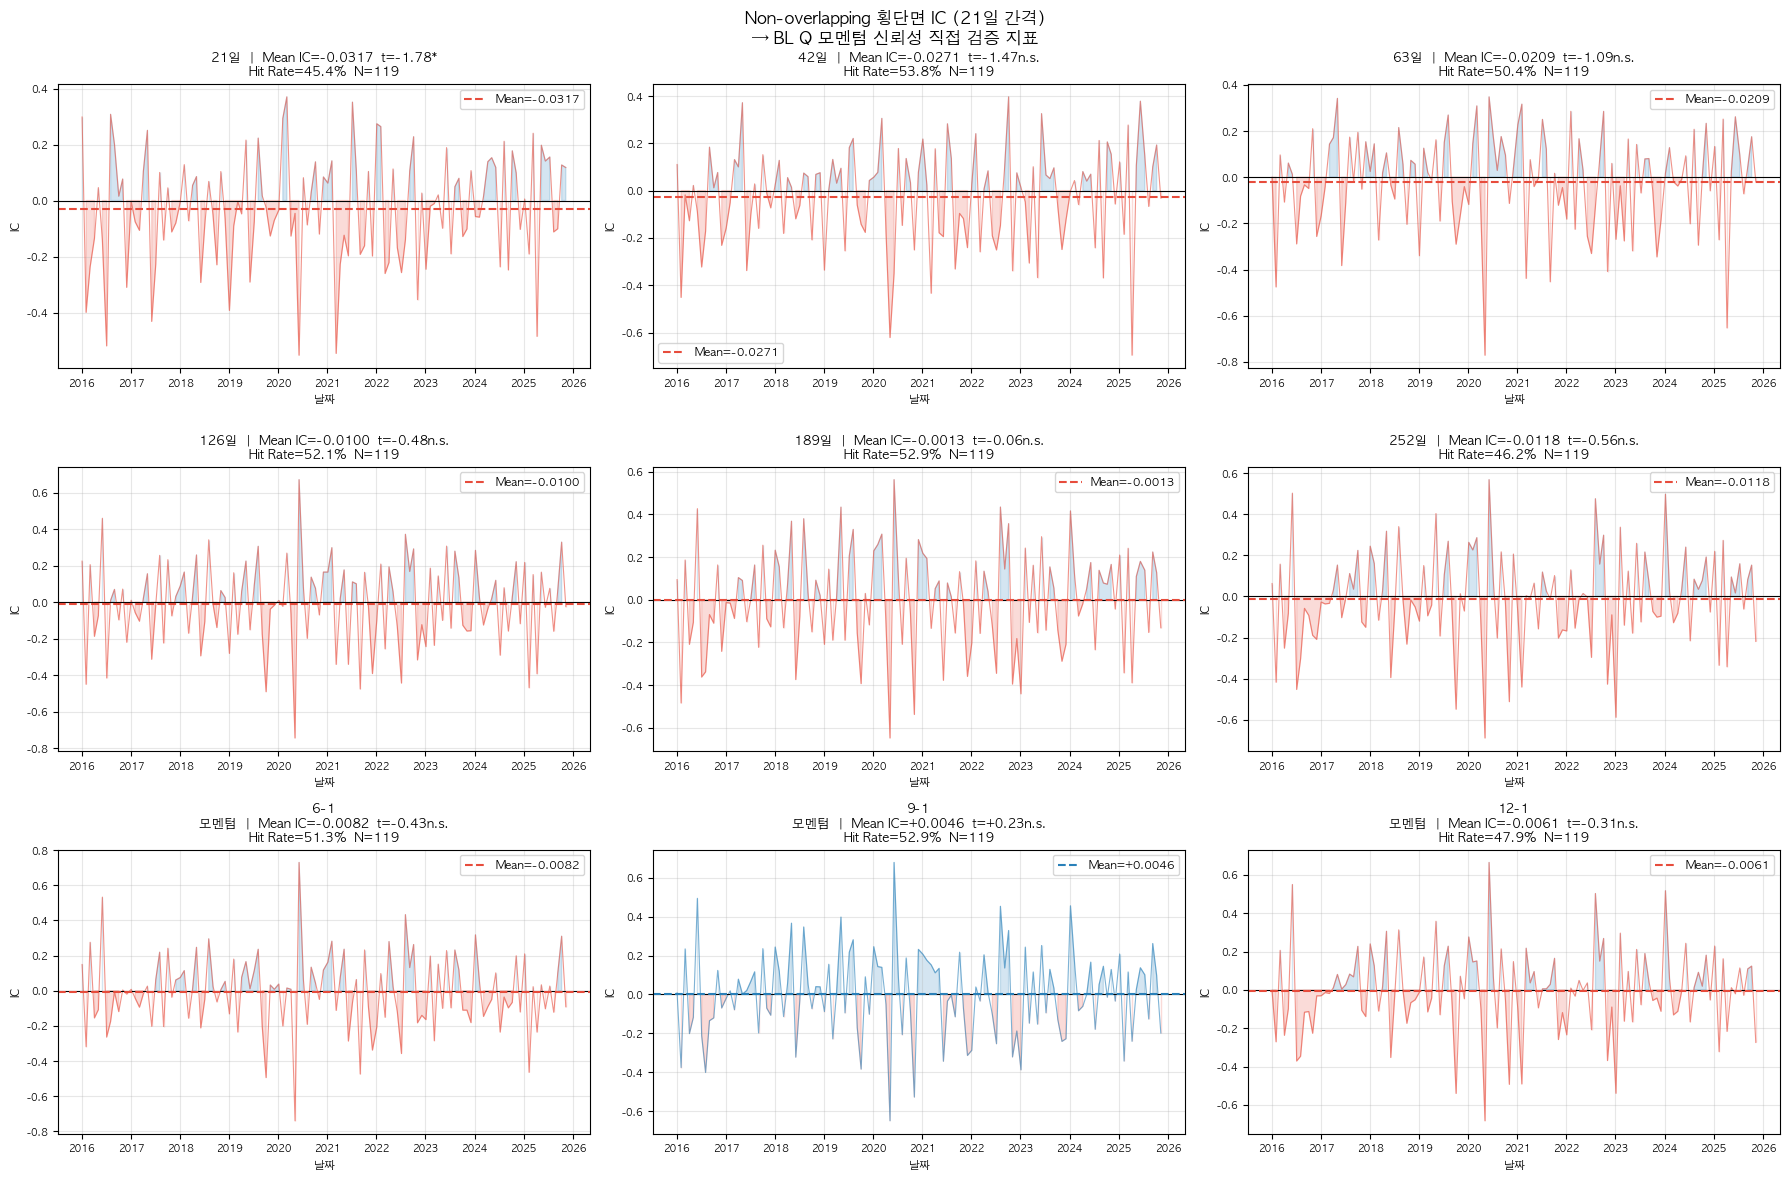

저장: images/step5_eda_nonoverlap_ic.png


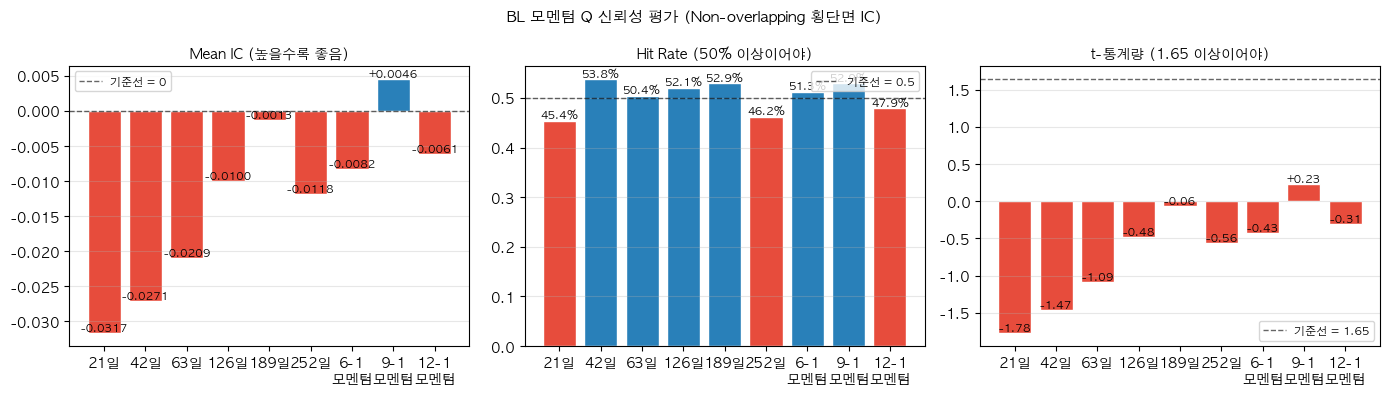

저장: images/step5_eda_ic_summary.png

✓ 선정된 최적 모멘텀 윈도우: (21, 42, 63) (절댓값 기준 (양수 IC 부족))
  양수 IC 윈도우: ['9-1']


In [11]:
from scipy.stats import spearmanr, ttest_1samp
import warnings
warnings.filterwarnings('ignore')

WINDOWS_EDA  = [21, 42, 63, 126, 189, 252, '6-1', '9-1', '12-1']
# 앞 6개: 원본 모멘텀 / 뒤 3개: skip-1 버전 (단기반전 제거, Fama-French 표준)
# 6-1=shift(21).pct_change(105), 9-1=pct_change(168), 12-1=pct_change(231)
SKIP_WIN_MAP = {'6-1': (21,105), '9-1': (21,168), '12-1': (21,231)}
FORWARD_DAYS = 21   # 리밸런싱 주기 = 선행수익률 기간

# ── 전체 가격 데이터 결합 (주식 + 채권) ──────────────────────────────────
prices_all = prices.reindex(
    prices.index.union(bond_prices.index)
).combine_first(bond_prices)
prices_all = prices_all.sort_index().ffill()

# ── 핵심 함수: Non-overlapping 횡단면 IC ─────────────────────────────────
def compute_nonoverlap_cs_ic(prices_df, window, forward_days=FORWARD_DAYS,
                              start=ANALYSIS_START, step=None):
    """
    Non-overlapping 횡단면 IC

    매 step(=forward_days=21)거래일마다 한 번씩 IC 계산.
    선행수익률이 겹치지 않아 자기상관 없이 t-통계량 신뢰 가능.

    Parameters
    ----------
    window       : 모멘텀 계산 기간 (예: 126일)
    forward_days : 선행수익률 기간 (= 리밸런싱 주기 = 21일)
    step         : IC 샘플링 간격 (None이면 forward_days와 동일)

    Returns
    -------
    DataFrame with columns ['ic'], index=date
    """
    step = step or forward_days
    dates_full = prices_df.loc[start:].index
    # X-1 모멘텀: 최근 21일 skip으로 단기반전 노이즈 제거 (Fama-French 표준)
    if window in SKIP_WIN_MAP:
        skip, lookback = SKIP_WIN_MAP[window]
        momentum = prices_df.shift(skip).pct_change(lookback)
    else:
        momentum = prices_df.pct_change(window)
    future_r = prices_df.pct_change(forward_days).shift(-forward_days)

    ic_list = []
    # step 간격으로 샘플링 → 비겹침 보장
    for i in range(0, len(dates_full) - forward_days, step):
        t = dates_full[i]
        mom_row = momentum.loc[t].dropna()
        fut_row = future_r.loc[t].reindex(mom_row.index).dropna()
        common  = mom_row.index.intersection(fut_row.index)
        if len(common) < 5:
            continue
        ic, _ = spearmanr(mom_row[common], fut_row[common])
        ic_list.append({'date': t, 'ic': ic})

    return pd.DataFrame(ic_list).set_index('date') if ic_list else pd.DataFrame()


# ── 윈도우별 Non-overlapping IC 계산 ─────────────────────────────────────
print("Non-overlapping 횡단면 IC 계산 중 (21일 간격)...")
print(f"{'윈도우':>6s} | {'관측수':>5s} | {'Mean IC':>9s} | {'Std IC':>8s} | {'t-stat':>7s} | {'p-val':>7s} | {'Hit Rate':>9s} | 유의성")
print("-" * 80)

ic_nonoverlap = {}
for w in WINDOWS_EDA:
    df = compute_nonoverlap_cs_ic(prices_all, w)
    if df.empty:
        continue
    ic_nonoverlap[w] = df
    series = df['ic'].dropna()
    n       = len(series)
    mean_ic = series.mean()
    std_ic  = series.std()
    t_stat  = mean_ic / (std_ic / np.sqrt(n)) if std_ic > 0 else 0
    # 단측 t-검정 (H1: mean IC > 0)
    from scipy.stats import t as t_dist
    p_val   = t_dist.sf(t_stat, df=n-1)
    hit_rate = (series > 0).mean()
    sig = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else ''))
    w_label = w if isinstance(w, str) else f"{w}일"
    print(f"{w_label:>8s} | {n:>5d} | {mean_ic:>+9.4f} | {std_ic:>8.4f} | {t_stat:>+7.2f} | {p_val:>7.4f} | {hit_rate:>9.1%} | {sig}")

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, w in zip(axes, WINDOWS_EDA):
    if w not in ic_nonoverlap:
        ax.set_visible(False)
        continue
    df = ic_nonoverlap[w]
    series = df['ic'].dropna()
    mean_ic = series.mean()
    t_stat  = mean_ic / (series.std() / np.sqrt(len(series)))
    hit     = (series > 0).mean()

    # IC 시계열
    color = '#2980b9' if mean_ic >= 0 else '#e74c3c'
    ax.plot(df.index, df['ic'], color=color, alpha=0.6, linewidth=0.8)
    ax.axhline(0,        color='black',  linewidth=0.8)
    ax.axhline(mean_ic,  color=color,    linewidth=1.5, linestyle='--',
               label=f'Mean={mean_ic:+.4f}')
    ax.fill_between(df.index, df['ic'], 0,
                    where=df['ic'] > 0, alpha=0.2, color='#2980b9')
    ax.fill_between(df.index, df['ic'], 0,
                    where=df['ic'] < 0, alpha=0.2, color='#e74c3c')

    sig_str = '***' if abs(t_stat) > 2.58 else ('**' if abs(t_stat) > 1.96 else
              ('*' if abs(t_stat) > 1.65 else 'n.s.'))
    win_label = f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일'
    ax.set_title(f'{win_label}  |  Mean IC={mean_ic:+.4f}  t={t_stat:+.2f}{sig_str}\n'
                 f'Hit Rate={hit:.1%}  N={len(series)}', fontsize=9)
    ax.set_xlabel('날짜', fontsize=8)
    ax.set_ylabel('IC', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

plt.suptitle('Non-overlapping 횡단면 IC (21일 간격)\n'
             '→ BL Q 모멘텀 신뢰성 직접 검증 지표', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES / 'step5_eda_nonoverlap_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: images/step5_eda_nonoverlap_ic.png")

# ── 요약 막대 차트 ────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
windows_sorted = sorted(ic_nonoverlap.keys(), key=lambda w: (1, int(w.split('-')[0])) if isinstance(w, str) else (0, w))
mean_ics   = [ic_nonoverlap[w]['ic'].mean() for w in windows_sorted]
hit_rates  = [(ic_nonoverlap[w]['ic'] > 0).mean() for w in windows_sorted]
t_stats    = [ic_nonoverlap[w]['ic'].mean() /
              (ic_nonoverlap[w]['ic'].std() / np.sqrt(len(ic_nonoverlap[w])))
              for w in windows_sorted]
xlabels = [f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일' for w in windows_sorted]

for ax2, vals, title, fmt, thresh in zip(
    axes2,
    [mean_ics, hit_rates, t_stats],
    ['Mean IC (높을수록 좋음)', 'Hit Rate (50% 이상이어야)', 't-통계량 (1.65 이상이어야)'],
    ['ic', 'pct', 'float'],
    [0, 0.5, 1.65]
):
    colors = ['#2980b9' if v >= thresh else '#e74c3c' for v in vals]
    bars = ax2.bar(xlabels, vals, color=colors, edgecolor='white')
    ax2.axhline(thresh, color='black', linewidth=1, linestyle='--', alpha=0.6,
               label=f'기준선 = {thresh}')
    ax2.set_title(title, fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        label = f'{v:+.4f}' if fmt == 'ic' else (f'{v:.1%}' if fmt == 'pct' else f'{v:+.2f}')
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 label, ha='center', va='bottom', fontsize=8)

plt.suptitle('BL 모멘텀 Q 신뢰성 평가 (Non-overlapping 횡단면 IC)', fontsize=11)
plt.tight_layout()
plt.savefig(IMAGES / 'step5_eda_ic_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: images/step5_eda_ic_summary.png")

# ── 최적 윈도우 결정 ──────────────────────────────────────────────────────
pos_windows = {w: ic_nonoverlap[w]['ic'].mean()
               for w in ic_nonoverlap if ic_nonoverlap[w]['ic'].mean() > 0}
if len(pos_windows) >= 3:
    ranked = sorted(pos_windows, key=lambda w: pos_windows[w], reverse=True)
    note = "양수 Mean IC 기준"
else:
    ranked = sorted(ic_nonoverlap.keys(),
                    key=lambda w: abs(ic_nonoverlap[w]['ic'].mean()), reverse=True)
    note = "절댓값 기준 (양수 IC 부족)"

OPTIMAL_WINDOWS = tuple(sorted(ranked[:3], key=lambda w: (1, int(w.split('-')[0])) if isinstance(w, str) else (0, w)))
print(f"\n✓ 선정된 최적 모멘텀 윈도우: {OPTIMAL_WINDOWS} ({note})")
print(f"  양수 IC 윈도우: {sorted(pos_windows.keys()) if pos_windows else '없음'}")

## 셀 8-C: 윈도우별 최적 자산 조합 및 IC 상세 시각화

각 모멘텀 윈도우를 "최적 윈도우"로 선택한 자산 목록과 해당 윈도우에서의 mean IC 확인.
- Non-overlapping 횡단면 IC 기반 (셀 8-B 결과 활용)
- **파란색(양수 IC)**: 모멘텀 지속 효과 → Q 신호 방향 올바름
- **빨간색(음수 IC)**: 반전 효과 → |IC| 기준 최적이지만 방향 반대

자산별 Non-overlapping IC 계산 중...
  완료: 61개 자산
  양수 IC 보유 자산: 42개
  모든 윈도우 음수 자산: 19개


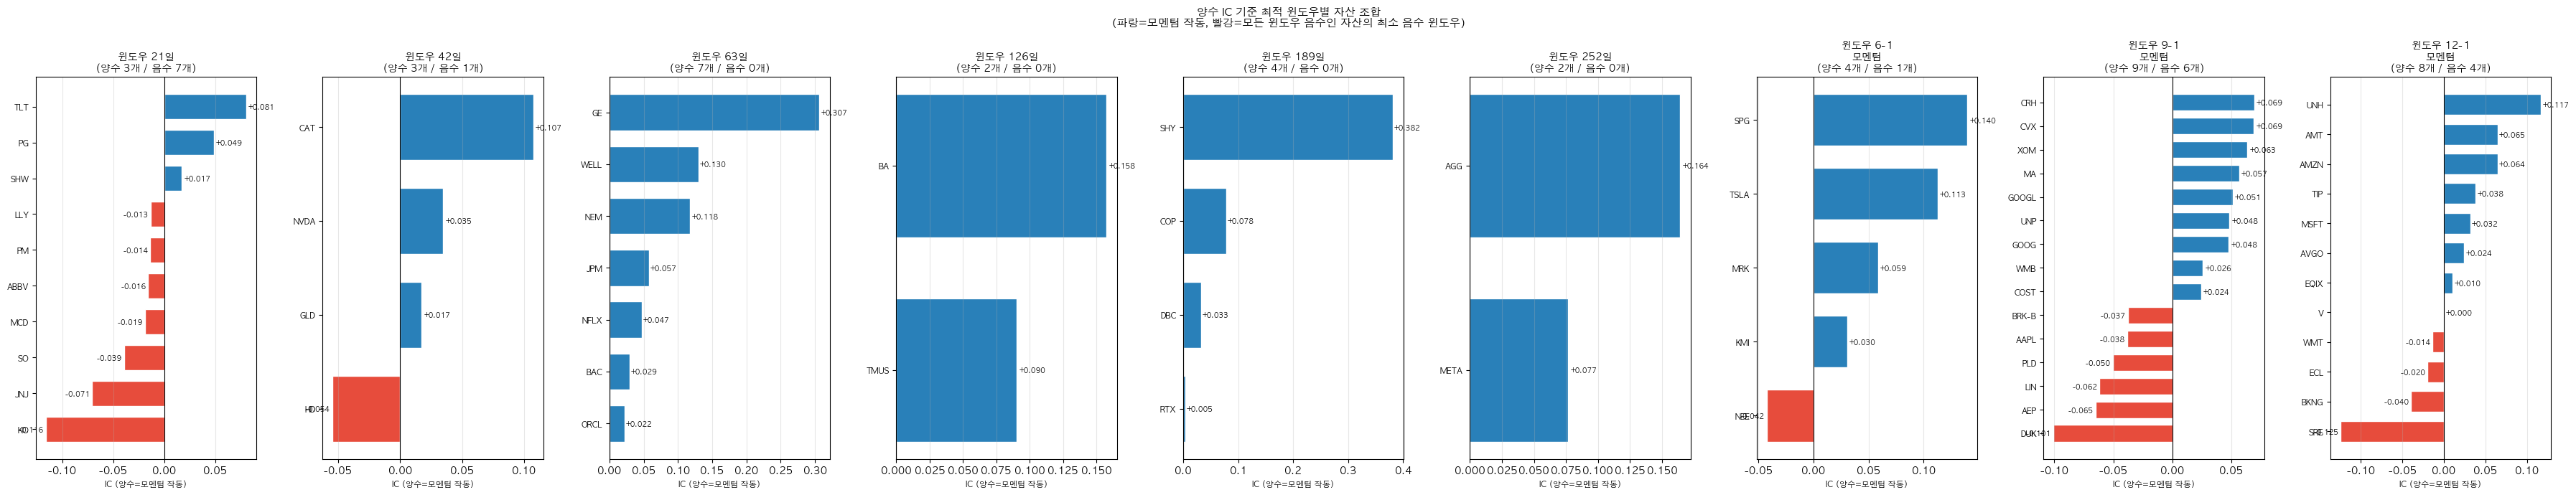

저장: images/step5_eda_window_assets_ic.png


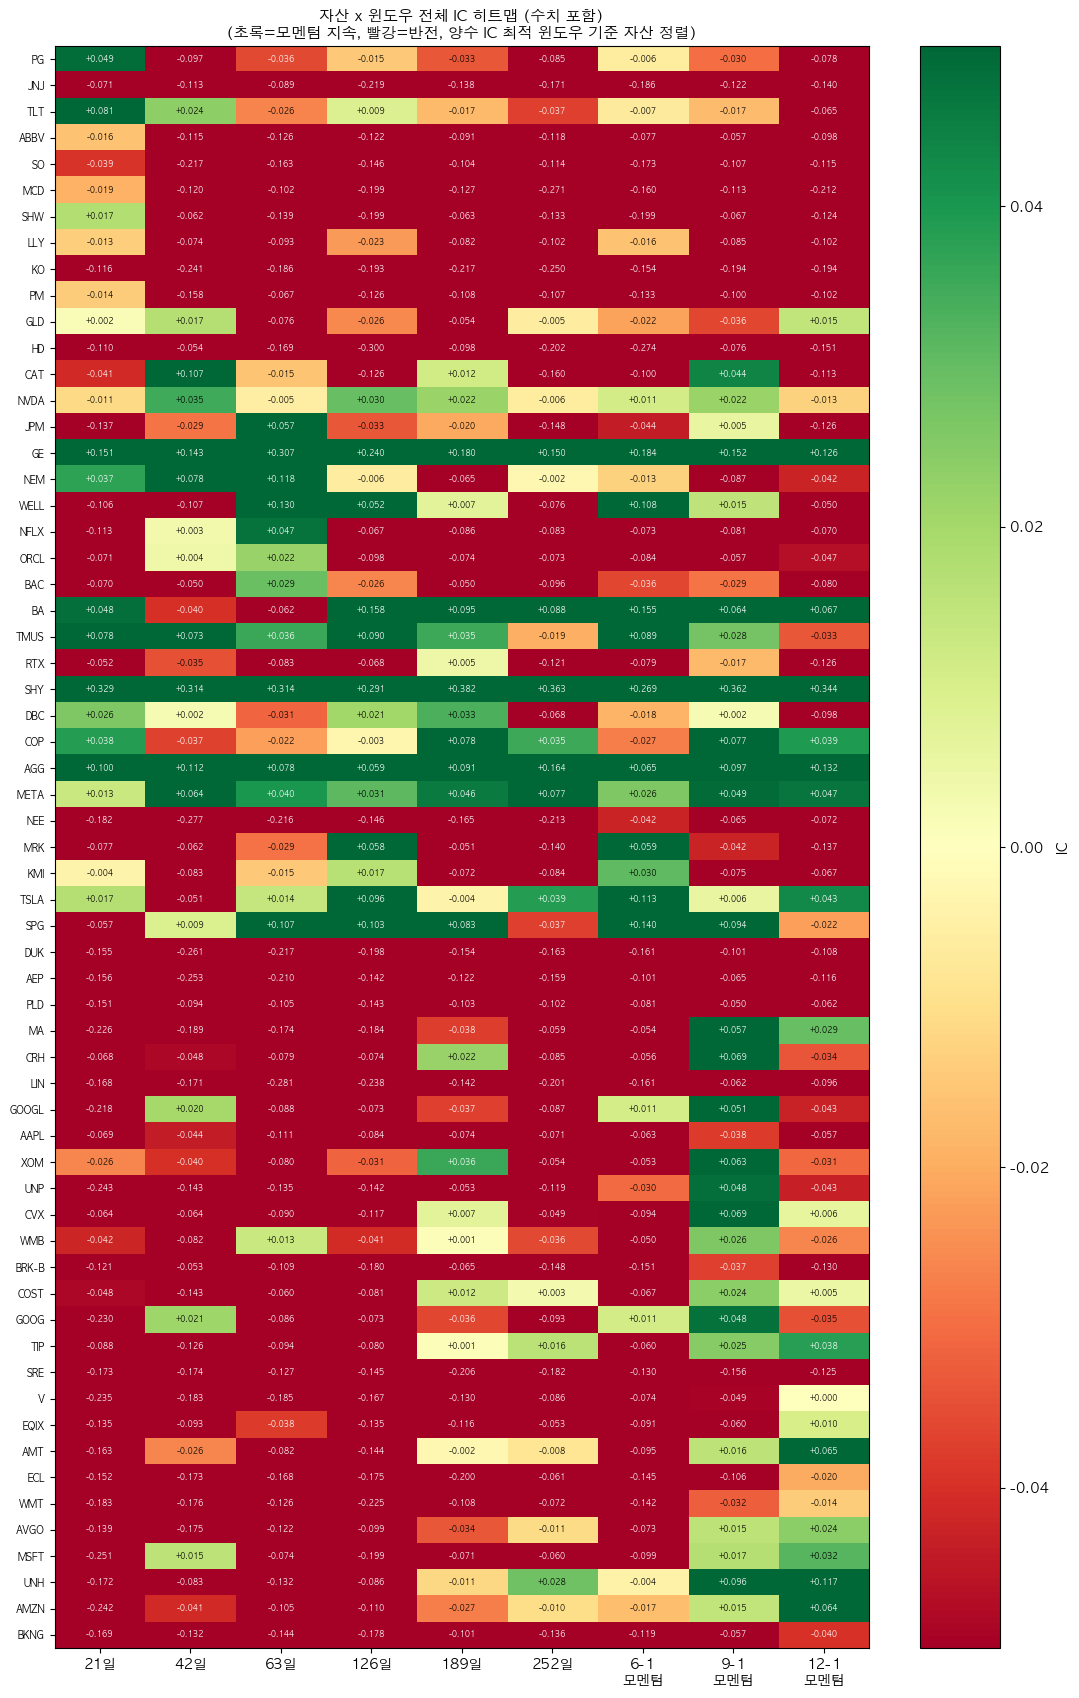

저장: images/step5_eda_ic_heatmap.png


In [12]:
# ── 단일 자산용 Non-overlapping 시계열 IC 함수 ───────────────────────────────
def compute_asset_nonoverlap_ic(price_series, window, forward_days=FORWARD_DAYS,
                                 start=ANALYSIS_START, step=None):
    step = step or forward_days
    dates_full = price_series.loc[start:].index
    if window in SKIP_WIN_MAP:
        skip, lookback = SKIP_WIN_MAP[window]
        momentum = price_series.shift(skip).pct_change(lookback)
    else:
        momentum = price_series.pct_change(window)
    future_r = price_series.pct_change(forward_days).shift(-forward_days)
    mom_vals, fut_vals = [], []
    for i in range(0, len(dates_full) - forward_days, step):
        t = dates_full[i]
        m = momentum.get(t, np.nan)
        f = future_r.get(t, np.nan)
        if pd.notna(m) and pd.notna(f):
            mom_vals.append(m)
            fut_vals.append(f)
    if len(mom_vals) < 10:
        return np.nan
    ic, _ = spearmanr(mom_vals, fut_vals)
    return ic


# ── 자산별 × 윈도우별 IC 계산 ─────────────────────────────────────────────
print('자산별 Non-overlapping IC 계산 중...')
SAMPLE_TICKERS = test_universe + BOND_TICKERS

asset_ic_table = {}
for ticker in SAMPLE_TICKERS:
    if ticker not in prices_all.columns:
        continue
    p_series = prices_all[ticker].dropna()
    ic_per_w = {}
    for w in WINDOWS_EDA:
        ic_val = compute_asset_nonoverlap_ic(p_series, w)
        if pd.notna(ic_val):
            ic_per_w[w] = ic_val
    if ic_per_w:
        asset_ic_table[ticker] = ic_per_w

print('  완료: {}개 자산'.format(len(asset_ic_table)))

# ── 자산별 최적 윈도우: 양수 IC 중 최대 / 없으면 음수 중 최소 절댓값 ─────────
# |IC| 최대 기준은 방향과 무관하게 극단값을 뽑아버림.
# 의미있는 기준 = '모멘텀이 실제로 작동하는(양수 IC) 최적 윈도우'
asset_best = {}
for ticker, ic_dict in asset_ic_table.items():
    pos = {w: v for w, v in ic_dict.items() if v > 0}
    if pos:
        asset_best[ticker] = max(pos, key=lambda w: pos[w])   # 양수 중 최대
    else:
        asset_best[ticker] = max(ic_dict, key=lambda w: ic_dict[w])  # 전부 음수면 최소 음수

pos_count = sum(1 for t, w in asset_best.items() if asset_ic_table[t][w] > 0)
neg_count = len(asset_best) - pos_count
print('  양수 IC 보유 자산: {}개'.format(pos_count))
print('  모든 윈도우 음수 자산: {}개'.format(neg_count))

# ── 윈도우별 자산 그룹화 ──────────────────────────────────────────────────
window_assets = {}
for ticker, best_w in asset_best.items():
    window_assets.setdefault(best_w, []).append(ticker)

active_windows = sorted(window_assets.keys(), key=lambda w: (1, int(w.split('-')[0])) if isinstance(w, str) else (0, w))
n_windows = len(active_windows)

if n_windows == 0:
    print('경고: 분석 가능한 자산 없음')
else:
    fig, axes = plt.subplots(1, n_windows, figsize=(4 * n_windows, 7))
    if n_windows == 1:
        axes = [axes]

    for ax, w in zip(axes, active_windows):
        tickers_in_w = window_assets[w]
        ic_vals = {t: asset_ic_table[t].get(w, 0.0) for t in tickers_in_w}
        sorted_items = sorted(ic_vals.items(), key=lambda x: x[1], reverse=True)
        labels = [t for t, _ in sorted_items]
        values = [v for _, v in sorted_items]
        colors = ['#2980b9' if v >= 0 else '#e74c3c' for v in values]

        ax.barh(range(len(labels)), values, color=colors, edgecolor='white', height=0.7)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        n_pos = sum(1 for v in values if v > 0)
        n_neg = sum(1 for v in values if v <= 0)
        win_label = '{}\n모멘텀'.format(w) if isinstance(w, str) else '{}일'.format(w)
        ax.set_title('윈도우 {}\n(양수 {}개 / 음수 {}개)'.format(win_label, n_pos, n_neg), fontsize=10)
        ax.set_xlabel('IC (양수=모멘텀 작동)', fontsize=8)
        ax.grid(True, alpha=0.3, axis='x')
        ax.invert_yaxis()
        for i, v in enumerate(values):
            offset = 0.002 if v >= 0 else -0.002
            ha = 'left' if v >= 0 else 'right'
            ax.text(v + offset, i, '{:+.3f}'.format(v), va='center', ha=ha, fontsize=7)

    plt.suptitle('양수 IC 기준 최적 윈도우별 자산 조합\n'
                 '(파랑=모멘텀 작동, 빨강=모든 윈도우 음수인 자산의 최소 음수 윈도우)',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(IMAGES / 'step5_eda_window_assets_ic.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: images/step5_eda_window_assets_ic.png')

# ── 자산 x 윈도우 IC 히트맵 (IC 수치 표시) ────────────────────────────────
ic_df = pd.DataFrame(asset_ic_table).T.reindex(columns=WINDOWS_EDA).fillna(0)
ic_df['best_window'] = pd.Series(asset_best)
ic_df = ic_df.iloc[pd.Categorical(
    ic_df['best_window'].astype(str),
    categories=[str(w) for w in sorted(
        set(ic_df['best_window']),
        key=lambda w: (1, int(str(w).split('-')[0])) if isinstance(w, str) and '-' in str(w) else (0, w)
    )],
    ordered=True
).argsort()]
ic_plot = ic_df.drop(columns='best_window')

fig2, ax2 = plt.subplots(figsize=(11, max(8, len(ic_plot) * 0.28)))
im = ax2.imshow(ic_plot.values, aspect='auto', cmap='RdYlGn', vmin=-0.05, vmax=0.05)
ax2.set_xticks(range(len(WINDOWS_EDA)))
ax2.set_xticklabels([f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일' for w in WINDOWS_EDA])
ax2.set_yticks(range(len(ic_plot)))
ax2.set_yticklabels(ic_plot.index, fontsize=7)
# IC 수치를 셀 안에 표시
for row_i in range(len(ic_plot)):
    for col_j in range(len(WINDOWS_EDA)):
        val = ic_plot.iloc[row_i, col_j]
        txt_color = 'white' if abs(val) > 0.035 else 'black'
        ax2.text(col_j, row_i, '{:+.3f}'.format(val),
                 ha='center', va='center', fontsize=5.5, color=txt_color)
plt.colorbar(im, ax=ax2, label='IC')
ax2.set_title('자산 x 윈도우 전체 IC 히트맵 (수치 포함)\n'
              '(초록=모멘텀 지속, 빨강=반전, 양수 IC 최적 윈도우 기준 자산 정렬)', fontsize=11)
plt.tight_layout()
plt.savefig(IMAGES / 'step5_eda_ic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5_eda_ic_heatmap.png')


## 셀 8-D: 자산별 모멘텀 윈도우 IC 상세 분석

전체 Mean IC는 모두 음수지만, **자산별로는 특정 윈도우에서 양수 IC가 나타날 수 있다.**

- 어떤 자산이 어느 윈도우에서 양수 IC를 보이는가?
- 양수 IC 기준 최적 윈도우 분포
- 자산별 6개 윈도우 IC 프로파일 → 모멘텀이 작동하는 자산군 확인

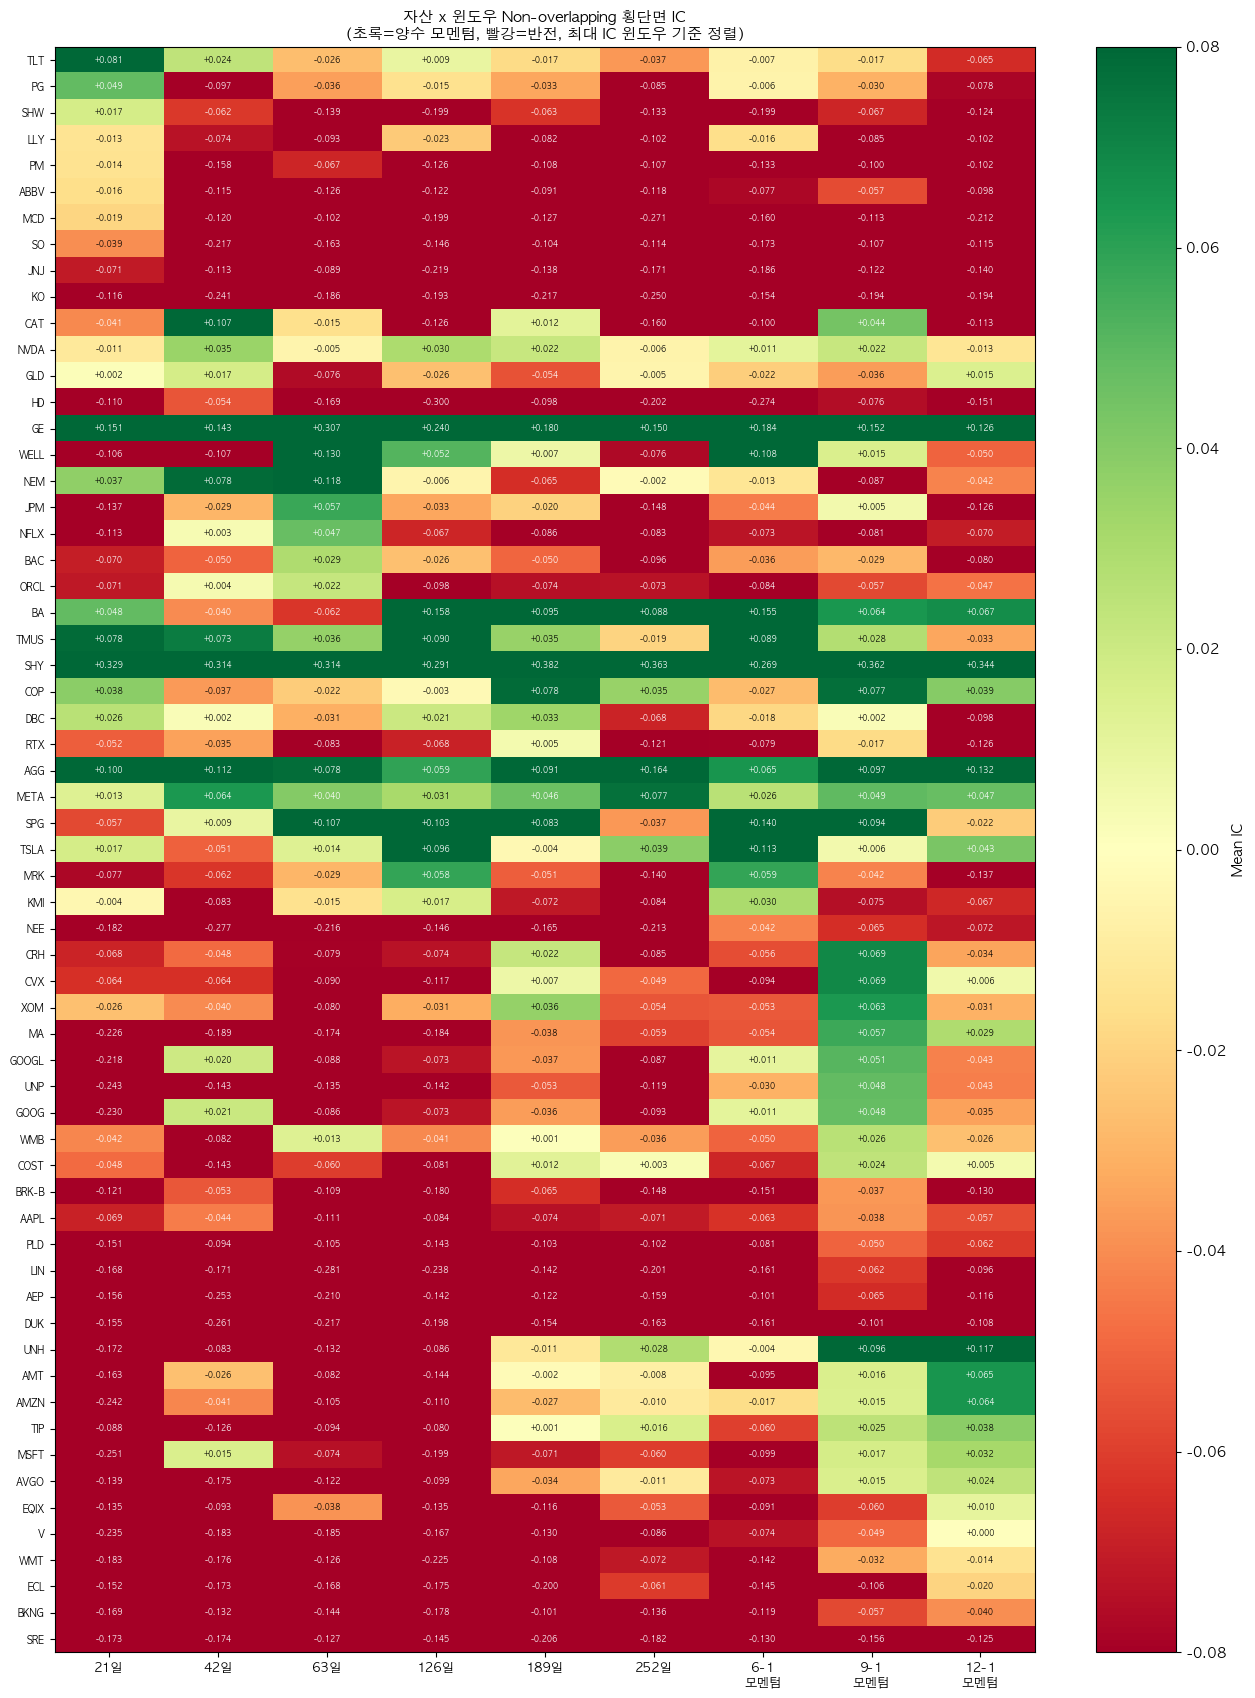

저장: images/step5_eda_asset_ic_heatmap_pos.png

양수 최대 IC 자산: 42개 / 전체 61개
음수 최대 IC 자산: 19개 (어떤 윈도우도 양수 IC 없음)


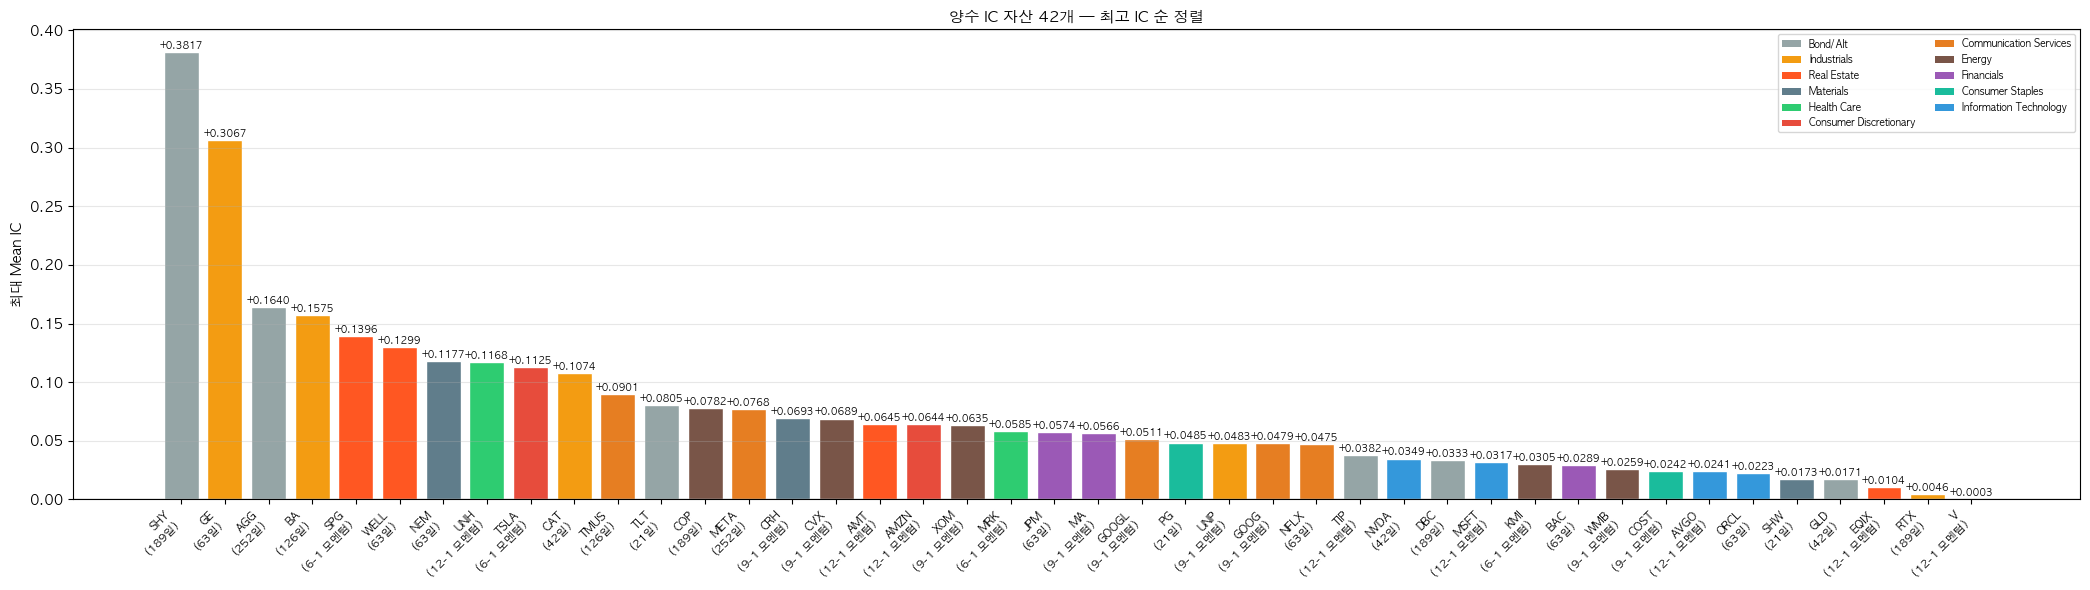

저장: images/step5_eda_pos_ic_assets.png


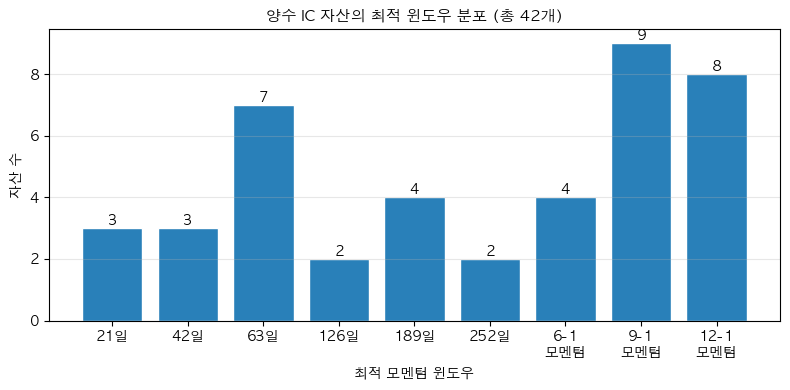

저장: images/step5_eda_pos_window_dist.png

=== 자산별 최대 IC 요약 ===
전체 61개 중 양수 IC 자산: 42개

  IC 상위 5개 자산:
    SHY      | 최적 윈도우=    189일 | Max IC=+0.3817 | Bond/Alt
    GE       | 최적 윈도우=     63일 | Max IC=+0.3067 | Industrials
    AGG      | 최적 윈도우=    252일 | Max IC=+0.1640 | Bond/Alt
    BA       | 최적 윈도우=    126일 | Max IC=+0.1575 | Industrials
    SPG      | 최적 윈도우= 6-1 모멘텀 | Max IC=+0.1396 | Real Estate


In [13]:
# asset_ic_table: {ticker: {window: mean_ic}} — 셀 8-C에서 계산
# 각 자산의 최대 IC(부호 포함)를 가진 윈도우 찾기

asset_best_pos = {}   # 최대 IC 윈도우 (양수 우선)
asset_max_ic   = {}   # 각 자산의 최고 IC 값

for ticker, ic_dict in asset_ic_table.items():
    best_w = max(ic_dict, key=lambda w: ic_dict[w])
    asset_best_pos[ticker] = best_w
    asset_max_ic[ticker]   = ic_dict[best_w]

def _win_sort_key(w):
    if isinstance(w, str) and '-' in str(w):
        return (1, int(str(w).split('-')[0]))
    return (0, w)

def _win_label(w):
    return f'{w}\n모멘텀' if isinstance(w, str) else f'{w}일'

# ── 1) 자산 x 윈도우 IC 히트맵 ────────────────────────────────────────────
ic_df = pd.DataFrame(asset_ic_table).T.reindex(columns=WINDOWS_EDA).fillna(0)
ic_df['best_pos_w'] = pd.Series(asset_best_pos)
ic_df['max_ic']     = pd.Series(asset_max_ic)
ic_df['_sort_key'] = ic_df['best_pos_w'].apply(_win_sort_key)
ic_df = ic_df.sort_values(['_sort_key', 'max_ic'], ascending=[True, False]).drop(columns='_sort_key')
ic_plot = ic_df.drop(columns=['best_pos_w', 'max_ic'])

n_assets = len(ic_plot)
fig1, ax1 = plt.subplots(figsize=(13, max(10, n_assets * 0.28)))
im = ax1.imshow(ic_plot.values, aspect='auto', cmap='RdYlGn', vmin=-0.08, vmax=0.08)
ax1.set_xticks(range(len(WINDOWS_EDA)))
ax1.set_xticklabels([_win_label(w) for w in WINDOWS_EDA], fontsize=9)
ax1.set_yticks(range(n_assets))
ax1.set_yticklabels(ic_plot.index, fontsize=7)
for row_i in range(n_assets):
    for col_j in range(len(WINDOWS_EDA)):
        val = ic_plot.iloc[row_i, col_j]
        color = 'white' if abs(val) > 0.04 else 'black'
        ax1.text(col_j, row_i, '{:+.3f}'.format(val), ha='center', va='center',
                 fontsize=5.5, color=color)
plt.colorbar(im, ax=ax1, label='Mean IC')
ax1.set_title('자산 x 윈도우 Non-overlapping 횡단면 IC\n'
              '(초록=양수 모멘텀, 빨강=반전, 최대 IC 윈도우 기준 정렬)', fontsize=11)
plt.tight_layout()
plt.savefig(IMAGES / 'step5_eda_asset_ic_heatmap_pos.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5_eda_asset_ic_heatmap_pos.png')

# ── 2) 양수 IC 자산 막대 차트 + 윈도우 분포 ──────────────────────────────
pos_assets = {t: v for t, v in asset_max_ic.items() if v > 0}
neg_assets  = {t: v for t, v in asset_max_ic.items() if v <= 0}
print('\n양수 최대 IC 자산: {}개 / 전체 {}개'.format(len(pos_assets), len(asset_max_ic)))
print('음수 최대 IC 자산: {}개 (어떤 윈도우도 양수 IC 없음)'.format(len(neg_assets)))

if pos_assets:
    sorted_pos = sorted(pos_assets.items(), key=lambda x: x[1], reverse=True)
    tickers_p = [t for t, _ in sorted_pos]
    values_p  = [v for _, v in sorted_pos]
    best_w_p  = [asset_best_pos[t] for t in tickers_p]
    sector_p  = ['Bond/Alt' if t in BOND_TICKERS else TICKER_TO_SECTOR.get(t, '기타')
                 for t in tickers_p]
    sector_colors = {
        'Information Technology': '#3498db', 'Health Care': '#2ecc71',
        'Financials': '#9b59b6', 'Communication Services': '#e67e22',
        'Consumer Discretionary': '#e74c3c', 'Consumer Staples': '#1abc9c',
        'Industrials': '#f39c12', 'Energy': '#795548', 'Materials': '#607d8b',
        'Real Estate': '#ff5722', 'Utilities': '#00bcd4', 'Bond/Alt': '#95a5a6',
    }
    bar_colors = [sector_colors.get(s, '#7f8c8d') for s in sector_p]

    fig2, ax2 = plt.subplots(figsize=(max(12, len(tickers_p) * 0.5), 6))
    bars = ax2.bar(range(len(tickers_p)), values_p, color=bar_colors, edgecolor='white')
    ax2.set_xticks(range(len(tickers_p)))
    ax2.set_xticklabels(
        [t + '\n(' + _win_label(w).replace('\n', ' ') + ')' for t, w in zip(tickers_p, best_w_p)],
        rotation=45, ha='right', fontsize=8
    )
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('최대 Mean IC')
    ax2.set_title('양수 IC 자산 {}개 — 최고 IC 순 정렬'.format(len(pos_assets)), fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, values_p):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                 '{:+.4f}'.format(v), ha='center', va='bottom', fontsize=7)
    from matplotlib.patches import Patch
    seen = {}
    for s, c in zip(sector_p, bar_colors):
        if s not in seen:
            seen[s] = c
    ax2.legend(handles=[Patch(facecolor=c, label=s) for s, c in seen.items()],
               loc='upper right', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(IMAGES / 'step5_eda_pos_ic_assets.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: images/step5_eda_pos_ic_assets.png')

    # 윈도우별 양수 IC 자산 수 분포
    raw_counts = pd.Series([asset_best_pos[t] for t in pos_assets]).value_counts()
    sorted_idx = sorted(raw_counts.index, key=_win_sort_key)
    win_counts = raw_counts[sorted_idx]

    fig3, ax3 = plt.subplots(figsize=(8, 4))
    ax3.bar([_win_label(w) for w in win_counts.index], win_counts.values,
            color='#2980b9', edgecolor='white')
    for i, v in enumerate(win_counts.values):
        ax3.text(i, v, str(v), ha='center', va='bottom', fontsize=10)
    ax3.set_title('양수 IC 자산의 최적 윈도우 분포 (총 {}개)'.format(len(pos_assets)), fontsize=11)
    ax3.set_xlabel('최적 모멘텀 윈도우')
    ax3.set_ylabel('자산 수')
    ax3.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(IMAGES / 'step5_eda_pos_window_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: images/step5_eda_pos_window_dist.png')
else:
    print('  → 어떤 윈도우에서도 양수 IC를 가진 자산이 없음')

# ── 요약 ─────────────────────────────────────────────────────────────────
print('\n=== 자산별 최대 IC 요약 ===')
print('전체 {}개 중 양수 IC 자산: {}개'.format(len(asset_max_ic), len(pos_assets)))
if pos_assets:
    top5 = sorted(pos_assets.items(), key=lambda x: x[1], reverse=True)[:5]
    print('\n  IC 상위 5개 자산:')
    for t, v in top5:
        w   = asset_best_pos[t]
        sec = 'Bond/Alt' if t in BOND_TICKERS else TICKER_TO_SECTOR.get(t, '기타')
        print('    {:8s} | 최적 윈도우={:>8s} | Max IC={:+.4f} | {}'.format(
            t, _win_label(w).replace('\n', ' '), v, sec))


## 셀 8-E: 자산유형별 IC 근거 시각화 — 주식 vs 채권 윈도우 선택 근거

**목적**: 모멘텀 윈도우를 자산 유형별로 고정 설정하는 근거를 두 유니버스에서 확인

| 자산 유형 | 채택 윈도우 | 근거 |
|-----------|-------------|------|
| 주식 | 63 / 126 / 189일 평균 | 중단기에서 IC 상대적으로 덜 음수 |
| 채권/대안 | 126 / 189 / 252일 평균 | 장기에서 IC 양수 (금리 추세 지속성) |

**Look-ahead bias 없음** — IC 분석은 근거 확인용이며, 백테스트는 고정 규칙만 사용

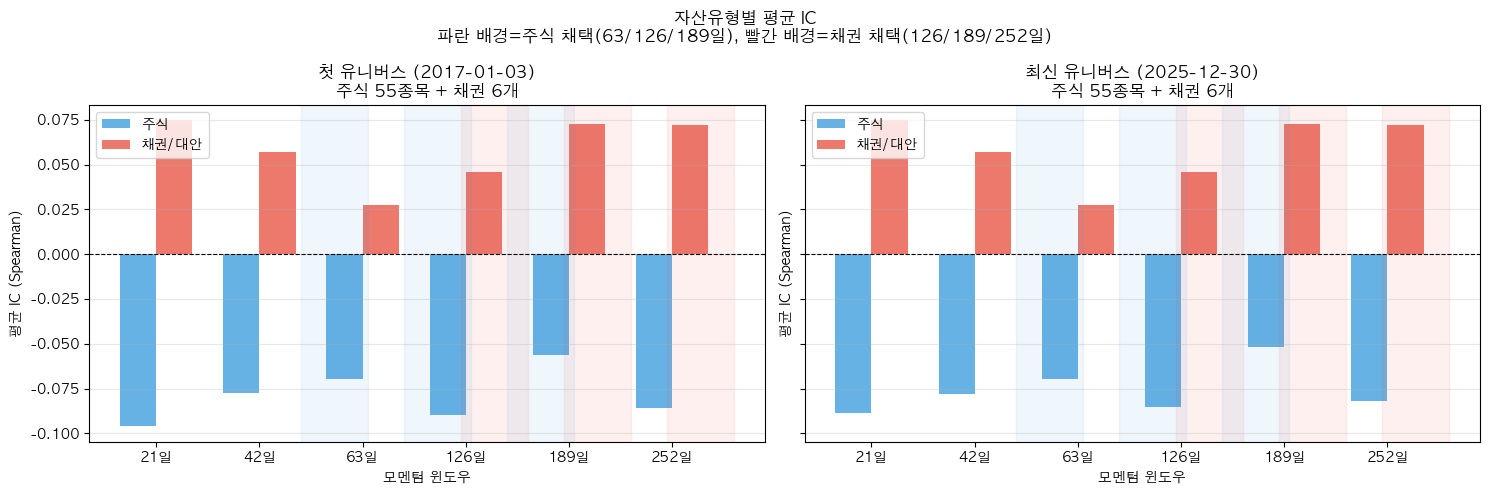

=== 최신 유니버스 기준 자산유형별 평균 IC ===
     윈도우       주식 IC       채권 IC       채권-주식
---------------------------------------------
    21일     -0.0885     +0.0748     +0.1634
    42일     -0.0780     +0.0572     +0.1352
    63일     -0.0696     +0.0274     +0.0970
   126일     -0.0855     +0.0457     +0.1311
   189일     -0.0516     +0.0725     +0.1241
   252일     -0.0817     +0.0720     +0.1537

→ 주식 채택 윈도우: (63, 126, 189) (덜 음수인 중단기)
→ 채권 채택 윈도우: (126, 189, 252) (양수 IC 구간)


In [14]:
# ── 자산유형별 IC 근거 시각화: 첫 유니버스 vs 최신 유니버스 ─────────────────────
EQUITY_WINDOWS = (63, 126, 189)
BOND_WINDOWS   = (126, 189, 252)
INT_WINDOWS    = [21, 42, 63, 126, 189, 252]

def type_mean_ic(eq_univ, bond_tks, ic_table, windows):
    """유니버스 내 equity/bond 분리 후 윈도우별 평균 IC 반환"""
    eq_ic   = {w: [] for w in windows}
    bond_ic = {w: [] for w in windows}
    for t, ic_dict in ic_table.items():
        for w in windows:
            if w not in ic_dict:
                continue
            if t in bond_tks:
                bond_ic[w].append(ic_dict[w])
            elif t in eq_univ:
                eq_ic[w].append(ic_dict[w])
    return (
        {w: float(np.mean(v)) if v else np.nan for w, v in eq_ic.items()},
        {w: float(np.mean(v)) if v else np.nan for w, v in bond_ic.items()}
    )

# ── 첫 유니버스 (분석 시작 후 252거래일 시점 리밸런싱) ─────────────────────────
_first_idx  = prices_combined.loc[ANALYSIS_START:].index[252]
_first_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, _first_idx)
_first_eq, _, _ = select_universe_by_mcap(
    prices.loc[_first_idx], shares_dict, _first_pool, TOP_N
)

# ── 최신 유니버스 ──────────────────────────────────────────────────────────────
_latest_idx  = prices_combined.index[-1]
_latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, _latest_idx)
_latest_eq, _, _ = select_universe_by_mcap(
    prices.loc[min(_latest_idx, prices.index[-1])], shares_dict, _latest_pool, TOP_N
)

universes = [
    (f'첫 유니버스 ({_first_idx.date()})', _first_eq),
    (f'최신 유니버스 ({_latest_idx.date()})', _latest_eq),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
x = np.arange(len(INT_WINDOWS))
w_bar = 0.35

for ax, (title, eq_univ) in zip(axes, universes):
    eq_ic, bond_ic = type_mean_ic(eq_univ, BOND_TICKERS, asset_ic_table, INT_WINDOWS)
    eq_vals   = [eq_ic.get(w, np.nan)   for w in INT_WINDOWS]
    bond_vals = [bond_ic.get(w, np.nan) for w in INT_WINDOWS]

    ax.bar(x - w_bar/2, eq_vals,   w_bar, label='주식',    color='#3498db', alpha=0.75)
    ax.bar(x + w_bar/2, bond_vals, w_bar, label='채권/대안', color='#e74c3c', alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # 채택 윈도우 배경 강조
    for w in EQUITY_WINDOWS:
        if w in INT_WINDOWS:
            ax.axvspan(INT_WINDOWS.index(w) - w_bar - 0.25,
                       INT_WINDOWS.index(w) + 0.05, alpha=0.08, color='#3498db')
    for w in BOND_WINDOWS:
        if w in INT_WINDOWS:
            ax.axvspan(INT_WINDOWS.index(w) - 0.05,
                       INT_WINDOWS.index(w) + w_bar + 0.25, alpha=0.08, color='#e74c3c')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{w}일' for w in INT_WINDOWS])
    ax.set_xlabel('모멘텀 윈도우')
    ax.set_ylabel('평균 IC (Spearman)')
    ax.set_title(f'{title}\n주식 {len(eq_univ)}종목 + 채권 {len(BOND_TICKERS)}개')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('자산유형별 평균 IC\n'
             '파란 배경=주식 채택(63/126/189일), 빨간 배경=채권 채택(126/189/252일)',
             fontsize=12)
plt.tight_layout()
plt.savefig(IMAGES / 'type_ic_window_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────────────────────
print('=== 최신 유니버스 기준 자산유형별 평균 IC ===')
_eq_ic, _bd_ic = type_mean_ic(_latest_eq, BOND_TICKERS, asset_ic_table, INT_WINDOWS)
print(f'{'윈도우':>8}  {'주식 IC':>10}  {'채권 IC':>10}  {'채권-주식':>10}')
print('-' * 45)
for w in INT_WINDOWS:
    diff = (_bd_ic[w] - _eq_ic[w]) if not (np.isnan(_bd_ic[w]) or np.isnan(_eq_ic[w])) else np.nan
    print(f'{w:>6}일  {_eq_ic[w]:>+10.4f}  {_bd_ic[w]:>+10.4f}  {diff:>+10.4f}')
print(f'\n→ 주식 채택 윈도우: {EQUITY_WINDOWS} (덜 음수인 중단기)')
print(f'→ 채권 채택 윈도우: {BOND_WINDOWS} (양수 IC 구간)')


## 셀 9: Walk-Forward 백테스트

- **21거래일**: BL 기반 비중 리밸런싱
- **252거래일(1년)**: 유니버스 갱신 (시가총액 Top5 재선정)
- Look-ahead bias 없음: 각 시점에서 과거 데이터만 사용

In [ ]:
analysis_days = prices_combined.loc[ANALYSIS_START:].index
n_days = len(analysis_days)

# ── 초기 유니버스 ─────────────────────────────────────────────────────────
init_date  = analysis_days[0]
init_pool, init_excluded = filter_pool_by_date(sp500_snapshot, sp500_changes, init_date)
start_snap = prices.loc[init_date]
current_eq_univ, current_sector_map, _ = select_universe_by_mcap(
    start_snap, shares_dict, init_pool, TOP_N
)
n_eq = len(current_eq_univ)

def build_combined_universe(eq_univ, bond_tickers):
    return list(eq_univ) + [b for b in bond_tickers if b not in eq_univ]

current_universe = build_combined_universe(current_eq_univ, BOND_TICKERS)
n_all = len(current_universe)

current_weights = {p: pd.Series(1.0 / n_all, index=current_universe) for p in PROFILES}
current_weights['EqualWeight'] = pd.Series(1.0 / n_all, index=current_universe)

port_values         = {p: [1.0] for p in list(PROFILES.keys()) + ['EqualWeight']}
rebalance_log       = []
omega_analysis_logs = []
exclusion_rate      = []
active_count_log    = []


print(f'분석 기간: {analysis_days[0].date()} ~ {analysis_days[-1].date()} ({n_days}거래일)')
print(f'초기 유니버스: 주식 {n_eq}종목 + 채권/대안 {len(BOND_TICKERS)}개 = {n_all}개')
print(f'Step5A: 듀얼 모멘텀 필터 + 자산별 최적 Q | Prior: Risk Parity | Omega: Idzorek\n')

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]

    ret = {}
    for t in current_universe:
        if t in prices_combined.columns:
            p0 = prices_combined.at[prev_date, t] if prev_date in prices_combined.index else np.nan
            p1 = prices_combined.at[date, t]      if date      in prices_combined.index else np.nan
            ret[t] = (p1 / p0 - 1) if (pd.notna(p0) and pd.notna(p1) and p0 > 0) else 0.0
        else:
            ret[t] = 0.0

    for p in list(PROFILES.keys()) + ['EqualWeight']:
        w = current_weights[p]
        port_ret = sum(w.get(t, 0.0) * ret.get(t, 0.0) for t in current_universe)
        port_values[p].append(port_values[p][-1] * (1 + port_ret))

    if i % UNIVERSE_UPDATE_FREQ == 0:
        year_pool, year_excl = filter_pool_by_date(sp500_snapshot, sp500_changes, date)
        snap = prices.loc[date]
        new_eq_univ, new_sector_map, _ = select_universe_by_mcap(
            snap, shares_dict, year_pool, TOP_N
        )
        current_eq_univ    = new_eq_univ
        current_sector_map = new_sector_map
        current_universe   = build_combined_universe(current_eq_univ, BOND_TICKERS)
        n_all = len(current_universe)
        for p in list(PROFILES.keys()) + ['EqualWeight']:
            current_weights[p] = pd.Series(1.0 / n_all, index=current_universe)
        excl_str = f' (미편입 제외 {len(year_excl)}종목)' if year_excl else ''
        print(f'  [{date.date()}] 유니버스 갱신: 주식 {len(current_eq_univ)}+채권 {len(BOND_TICKERS)}{excl_str}')

    if i % REBALANCE_FREQ == 0:
        prices_win = prices_combined.loc[:date, current_universe]
        if len(prices_win) < COV_WIN + 253:
            continue

        # [Step5A] 절대 모멘텀 필터 — 12-1 수익률 < T-bill → 편출
        active_tickers, excluded_tickers = apply_absolute_momentum_filter(
            current_universe, prices_win, date, CACHE
        )
        n_active   = len(active_tickers)
        n_excluded = len(excluded_tickers)
        exclusion_rate.append(n_excluded / max(n_active + n_excluded, 1))
        active_count_log.append({'date': date, 'active': n_active, 'excluded': n_excluded})

        if n_active < 2:
            continue

        # 공분산: active 자산만
        active_win = prices_win[active_tickers]
        recent = active_win.iloc[-COV_WIN:]
        log_r  = np.log(recent / recent.shift(1)).dropna()
        if log_r.shape[0] < 60:
            continue

        lw = LedoitWolf()
        lw.fit(log_r)
        cov = lw.covariance_ * 252

        # Risk Parity Prior (active 자산만)
        pi_raw = compute_prior_risk_parity(cov, LAM)
        pi = pd.Series(pi_raw.values, index=active_tickers)

        # [Step5A] 자산별 최적 윈도우 Q
        Q = compute_momentum_Q(active_win, (126, 189, 252))
        Q = Q.reindex(active_tickers).fillna(0)

        omega, confidence = compute_omega_idzorek(Q, cov, TAU)
        mu_bl, sigma_bl = black_litterman(pi, cov, Q, omega, TAU)

        # Omega 분석 로그
        diag_omega = np.diag(omega)
        diag_prior_uncert = np.diag(TAU * cov)
        relative_uncertainty = diag_omega / (diag_prior_uncert + 1e-9)
        omega_analysis_logs.append({
            'date': date,
            'mean_confidence':      np.mean(confidence),
            'min_confidence':       np.min(confidence),
            'max_confidence':       np.max(confidence),
            'mean_omega':           np.mean(diag_omega),
            'mean_rel_uncertainty': np.mean(relative_uncertainty),
        })

        # active 자산 섹터 분리
        active_eq   = [t for t in current_eq_univ if t in active_tickers]
        active_bond = [t for t in BOND_TICKERS    if t in active_tickers]
        active_sm   = {s: [t for t in ts if t in active_tickers]
                       for s, ts in current_sector_map.items()}
        active_sm   = {s: ts for s, ts in active_sm.items() if ts}

        # MVO: active 자산만, 편출 자산 비중 0 → 재분배
        for p, prof in PROFILES.items():
            if not active_eq:
                current_weights[p] = pd.Series(0.0, index=current_universe)
                continue
            w_active = mvo_optimize_unified(
                mu_bl, sigma_bl, prof['gamma'],
                equity_tickers    = active_eq,
                bond_tickers      = active_bond,
                max_equity_weight = prof['max_equity_weight'],
                max_sector        = prof['max_sector'],
                sector_map        = active_sm,
                max_bond_total    = prof['max_bond_total'],
                max_single_bond   = prof['max_single_bond'],
            )
            w_full = pd.Series(0.0, index=current_universe)
            for t in active_tickers:
                if t in w_active.index:
                    w_full[t] = w_active[t]
            if w_full.sum() > 0:
                w_full /= w_full.sum()
            current_weights[p] = w_full

        # EqualWeight: active 자산만 등가중
        n_ew = max(n_active, 1)
        current_weights['EqualWeight'] = pd.Series(
            {t: (1.0/n_ew if t in active_tickers else 0.0) for t in current_universe}
        )
        rebalance_log.append({'date': date, 'n_assets': n_all, 'n_active': n_active})

print(f'\n백테스트 완료! 총 리밸런싱: {len(rebalance_log)}회')
if rebalance_log:
    last_w = current_weights.get('Neutral', pd.Series())
    bond_alloc = last_w.reindex(BOND_TICKERS).fillna(0).sum()
    print(f'최근 Neutral 채권/대안 비중: {bond_alloc:.1%}')

if omega_analysis_logs:
    om_df = pd.DataFrame(omega_analysis_logs)
    print()
    print('=' * 52)
    print('   [Black-Litterman Omega & Confidence 요약]')
    print('=' * 52)
    print(f'평균 신뢰도 (c):              {om_df["mean_confidence"].mean():.4f}')
    print(f'평균 상대적 불확실성 (Ω/τΣ): {om_df["mean_rel_uncertainty"].mean():.2f}배')
    print('─' * 52)
    print('※ 신뢰도(c)가 c_max(0.9)에 가까울수록 Q가 μ_BL에 강하게 반영됨')
    print('※ Ω/τΣ >> 1 이면 Prior(Risk Parity) 중심, ≈1 이면 Q와 균형')
    print('=' * 52)

if active_count_log:
    cnt_df = pd.DataFrame(active_count_log)
    avg_ex = np.mean(exclusion_rate) * 100
    print()
    print('=' * 52)
    print('   [듀얼 모멘텀 필터 — Active 종목 수]')
    print('=' * 52)
    print(f'전체 유니버스: {n_all}개 | 평균 active: {cnt_df["active"].mean():.1f}개 | 평균 편출: {avg_ex:.1f}%')
    print(f'최소 active: {cnt_df["active"].min()}개  |  최대 active: {cnt_df["active"].max()}개')
    print('=' * 52)


분석 기간: 2016-01-04 ~ 2025-12-30 (2513거래일)
초기 유니버스: 주식 55종목 + 채권/대안 6개 = 61개
Step5A: 듀얼 모멘텀 필터 + 자산별 최적 Q | Prior: Risk Parity | Omega: Idzorek

  [2017-01-03] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 103종목)
  [2018-01-03] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 83종목)
  [2019-01-04] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 74종목)
  [2020-01-06] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 58종목)
  [2021-01-05] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 50종목)
  [2022-01-04] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 40종목)
  [2023-01-05] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 28종목)
  [2024-01-08] 유니버스 갱신: 주식 55+채권 6 (미편입 제외 18종목)


## 셀 10: 성능 지표 계산

In [ ]:
def compute_metrics(values, dates_list):
    vals = np.array(values)
    rets = np.diff(vals) / vals[:-1]
    n_years = (pd.Timestamp(dates_list[-1]) - pd.Timestamp(dates_list[0])).days / 365.25
    total_ret = vals[-1] / vals[0] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    running_max = np.maximum.accumulate(vals)
    mdd = ((vals - running_max) / running_max).min()
    down = rets[rets < 0]
    sortino = ann_ret / (down.std() * np.sqrt(252)) if len(down) > 0 else 0
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    return {
        'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'mdd': mdd, 'sortino': sortino, 'calmar': calmar, 'total_return': total_ret
    }


dates = list(analysis_days)
metrics = {}
for p in list(PROFILES.keys()) + ['EqualWeight']:
    metrics[p] = compute_metrics(port_values[p], dates)

# SPY B&H 벤치마크
spy_cache = CACHE / 'spy_prices.pkl'
if spy_cache.exists():
    with open(spy_cache, 'rb') as f:
        spy_raw = pickle.load(f)
else:
    spy_raw = yf.download('SPY', start=ANALYSIS_START, end=PRICE_END, auto_adjust=True)['Close'].squeeze()
    with open(spy_cache, 'wb') as f:
        pickle.dump(spy_raw, f)

spy_aligned = spy_raw.loc[ANALYSIS_START:]
spy_norm = (spy_aligned / spy_aligned.iloc[0]).values
metrics['SPY_BnH'] = compute_metrics(spy_norm, list(spy_aligned.index))

# 출력
print('=== 성능 요약 ===')
header = f'{"전략":18s} {"연수익률":>10s} {"변동성":>10s} {"Sharpe":>8s} {"MDD":>10s} {"Sortino":>10s} {"Calmar":>8s}'
print(header)
print('-' * 80)
for name, m in metrics.items():
    print(f'{name:18s} {m["ann_return"]:>10.2%} {m["ann_vol"]:>10.2%} '
          f'{m["sharpe"]:>8.3f} {m["mdd"]:>10.2%} {m["sortino"]:>10.3f} {m["calmar"]:>8.3f}')

# CSV 저장
metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv(DATA / 'step5a_metrics.csv')
print('\n성능 지표 저장: data/step5_metrics.csv')

=== 성능 요약 ===
전략                       연수익률        변동성   Sharpe        MDD    Sortino   Calmar
--------------------------------------------------------------------------------
Aggressive             16.09%     24.32%    0.661    -34.68%      0.858    0.464
Neutral                15.00%     19.62%    0.764    -32.02%      0.972    0.468
Conservative           13.13%     16.63%    0.789    -28.03%      0.983    0.468
EqualWeight            13.22%     15.40%    0.859    -30.38%      1.025    0.435
SPY_BnH                14.98%     18.01%    0.832    -33.72%      0.999    0.444

성능 지표 저장: data/step5_metrics.csv


## 셀 11: 시각화

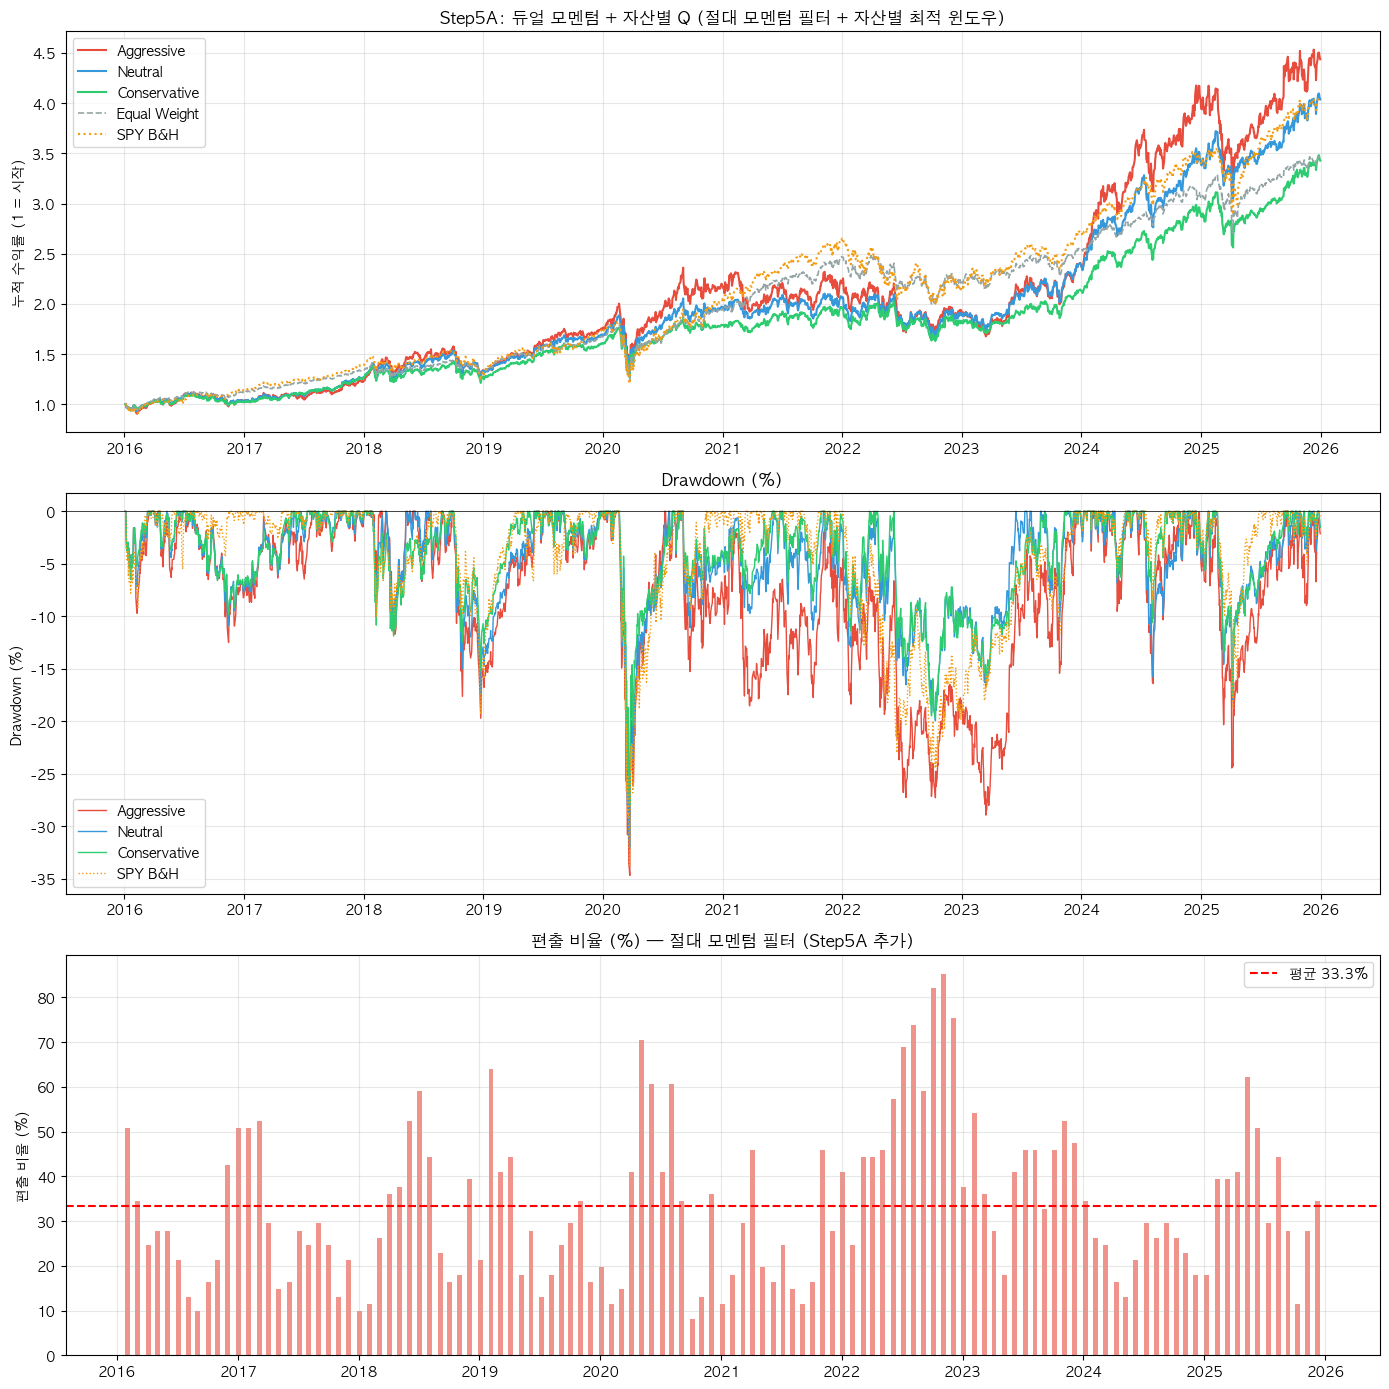

저장: images/step5a_01_cumulative.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

COLORS = {
    'Aggressive': '#e74c3c',
    'Neutral': '#3498db',
    'Conservative': '#2ecc71',
    'EqualWeight': '#95a5a6',
    'SPY_BnH': '#f39c12'
}

# ── 누적 수익률 ──────────────────────────────────
ax = axes[0]
for p in PROFILES:
    ax.plot(dates, port_values[p], label=p, color=COLORS[p], linewidth=1.5)
ax.plot(dates, port_values['EqualWeight'],
        label='Equal Weight', color=COLORS['EqualWeight'], linewidth=1.2, linestyle='--')

spy_dates = list(spy_aligned.index)
ax.plot(spy_dates, spy_norm, label='SPY B&H', color=COLORS['SPY_BnH'], linewidth=1.5, linestyle=':')

ax.set_title('Step5A: 듀얼 모멘텀 + 자산별 Q (절대 모멘텀 필터 + 자산별 최적 윈도우)',
             fontsize=12)
ax.set_ylabel('누적 수익률 (1 = 시작)')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Drawdown ─────────────────────────────────────
ax2 = axes[1]
for p in PROFILES:
    vals = np.array(port_values[p])
    running_max = np.maximum.accumulate(vals)
    dd = (vals - running_max) / running_max * 100
    ax2.plot(dates, dd, label=p, color=COLORS[p], linewidth=1)

spy_vals = spy_norm
spy_rmax = np.maximum.accumulate(spy_vals)
spy_dd = (spy_vals - spy_rmax) / spy_rmax * 100
ax2.plot(spy_dates, spy_dd, label='SPY B&H', color=COLORS['SPY_BnH'], linestyle=':', linewidth=1)

ax2.set_title('Drawdown (%)')
ax2.set_ylabel('Drawdown (%)')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── 편출 비율 (Step5A 추가) ───────────────────────────────────────────
if active_count_log:
    ax3 = axes[2]
    cnt_df2 = pd.DataFrame(active_count_log)
    ax3.bar(cnt_df2['date'], (cnt_df2['excluded'] / 61 * 100),
            color='#e74c3c', alpha=0.6, width=15)
    ax3.axhline(np.mean(exclusion_rate)*100, color='red', linestyle='--',
                label=f'평균 {np.mean(exclusion_rate)*100:.1f}%')
    ax3.set_title('편출 비율 (%) — 절대 모멘텀 필터 (Step5A 추가)')
    ax3.set_ylabel('편출 비율 (%)')
    ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / 'step5a_01_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5a_01_cumulative.png')

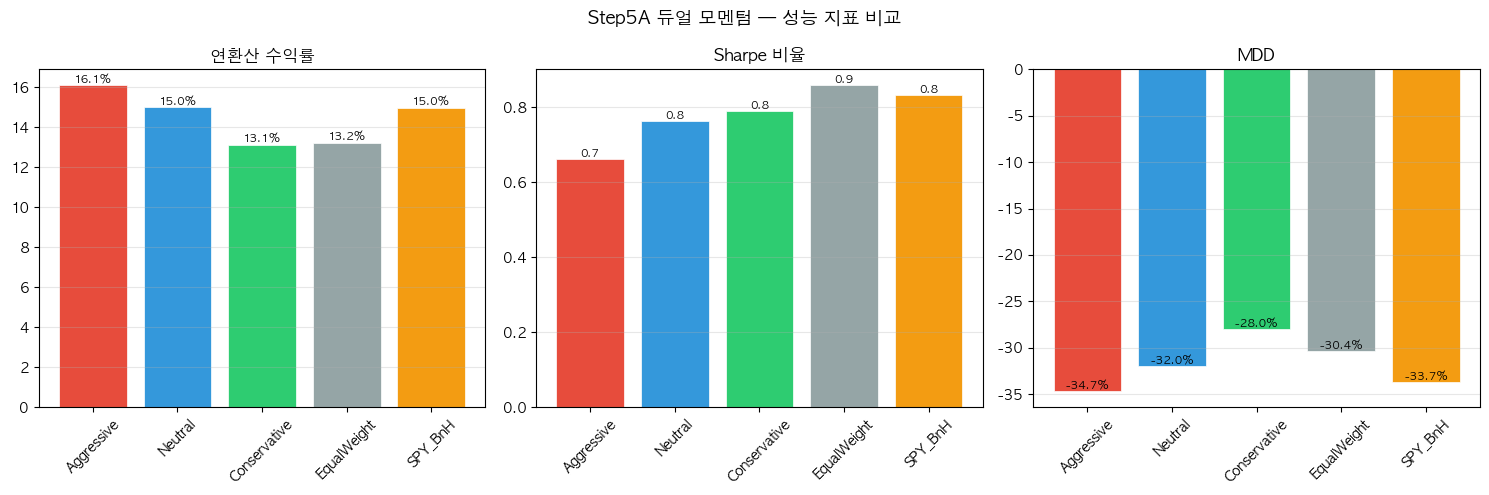

저장: images/step5a_02_metrics.png


In [ ]:
# 성능 지표 바차트
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(metrics.keys())
colors_list = [COLORS.get(n, '#7f8c8d') for n in names]

for ax, metric, title, fmt in zip(
    axes,
    ['ann_return', 'sharpe', 'mdd'],
    ['연환산 수익률', 'Sharpe 비율', 'MDD'],
    ['percent', 'float', 'percent']
):
    vals_plot = [metrics[n][metric] * (100 if fmt == 'percent' else 1) for n in names]
    bars = ax.bar(names, vals_plot, color=colors_list, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    unit = '%' if fmt == 'percent' else ''
    for bar, v in zip(bars, vals_plot):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.1f}{unit}', ha='center', va='bottom', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Step5A 듀얼 모멘텀 — 성능 지표 비교', fontsize=13)
plt.tight_layout()
plt.savefig(IMAGES / 'step5a_02_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5a_02_metrics.png')